# 🩹 Comparing Skin Graft Samples: Differential Gene Expression (DGE) Analysis

The skin graft dataset includes **six pairwise comparisons**, split by timepoint (**24h** and **72h**).  
Each comparison defines *case* and *control* sample groups used for pseudobulk differential expression analysis.

---

## ⏱️ 24-hour Comparisons

1. **cre_24h vs litt_24h**  
   - **Case:** `output-XETG00045__0059976__cre_24h__20250725__091031`  
   - **Control:** `output-XETG00045__0059976__litt_24h__20250725__091031`  
   Tests for early gene expression differences between *cre* and *littermate* grafts after 24 hours.

2. **cre_24h vs wt_24h**  
   - **Case:** `output-XETG00045__0059976__cre_24h__20250725__091031`  
   - **Control:** `output-XETG00045__0059976__wt_24h__20250725__091031`  
   Evaluates how *cre* grafts differ transcriptionally from *wild-type* grafts at 24 hours post-transplant.

3. **litt_24h vs wt_24h**  
   - **Case:** `output-XETG00045__0059976__litt_24h__20250725__091031`  
   - **Control:** `output-XETG00045__0059976__wt_24h__20250725__091031`  
   Compares *littermate* and *wild-type* grafts to identify shared or background-dependent responses at 24 hours.

---

## ⏳ 72-hour Comparisons

4. **cre_72h vs litt_72h**  
   - **Case:** `output-XETG00045__0059976__cre_72h__20250725__091031`  
   - **Control:** `output-XETG00045__0059976__litt_72h__20250725__091031`  
   Tests for gene expression differences between *cre* and *littermate* grafts after 72 hours, capturing later transcriptional divergence.

5. **cre_72h vs wt_72h**  
   - **Case:** `output-XETG00045__0059976__cre_72h__20250725__091031`  
   - **Control:** `output-XETG00045__0059976__wt_72h__20250725__091031`  
   Evaluates persistent or late-stage transcriptional changes in *cre* grafts relative to *wild-type* controls at 72 hours.

6. **litt_72h vs wt_72h**  
   - **Case:** `output-XETG00045__0059976__litt_72h__20250725__091031`  
   - **Control:** `output-XETG00045__0059976__wt_72h__20250725__091031`  
   Compares *littermate* and *wild-type* grafts at 72 hours to isolate background or recovery-related effects.

---

Each comparison is run using **pseudobulk aggregation** followed by **Welch’s t-test** or **DESeq2** differential testing, depending on downstream workflow preferences.  
Results are saved per contrast as CSV tables containing *log2 fold change*, *p-value*, and *adjusted p-value* for all detected genes.


# Take away
From this analysis it is clear that we need to use another way to segment the cells. 

In [1]:
import scanpy as sc
import matplotlib.pyplot as plt

In [2]:
ad = sc.read_h5ad('../../data/talbot_xenium.h5ad')
ad = ad[ad.obs.tissue == 'skin']
ad

View of AnnData object with n_obs × n_vars = 223359 × 5006
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run', 'sample_folder', 'sample___', 'condition', 'tissue', 'genotype', 'timepoint', 'seg_method_short', 'n_genes_by_counts', 'sample_id'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    obsm: 'spatial'

In [3]:
ad.layers['raw'] = ad.X.copy()

## 🔍 Quick Clustering

This initial clustering is **independent of the differential gene expression (DGE)** analysis but serves as an important **sanity check**.  
By running a quick clustering on the dataset (e.g., using PCA, neighbors, and Leiden), you can verify that:

- Samples or cells group according to expected biological or experimental conditions  
- There are no major batch effects or mislabeled samples  
- The overall structure of the data makes sense before performing DGE

This step helps ensure that downstream comparisons are biologically meaningful and not driven by technical artifacts.

In [4]:
sc.pp.calculate_qc_metrics(ad, percent_top=None, log1p=False, inplace=True)
sc.pp.filter_cells(ad,min_counts=30)
sc.pp.filter_cells(ad,min_genes=10)

In [5]:
ad.layers['counts'] = ad.X.copy()

In [6]:
sc.pp.normalize_total(ad, inplace=True,target_sum=100)
sc.pp.log1p(ad)

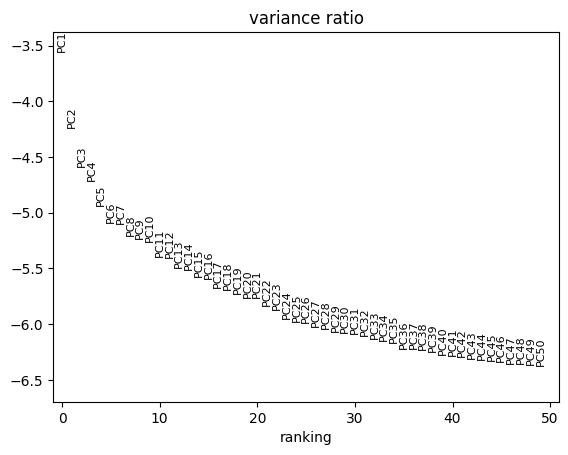

In [7]:
plt.rcdefaults()
sc.tl.pca(ad)
sc.pl.pca_variance_ratio(ad, n_pcs=50, log=True)
sc.pp.neighbors(ad, n_neighbors=15, n_pcs=30)

In [8]:
sc.tl.umap(ad, min_dist=0.1)

clustering at resolution 0.5


/Users/christoffer/miniconda3/envs/sc/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


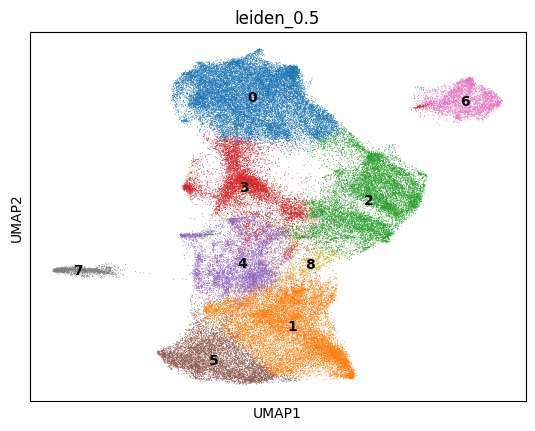

done
clustering at resolution 1


/Users/christoffer/miniconda3/envs/sc/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


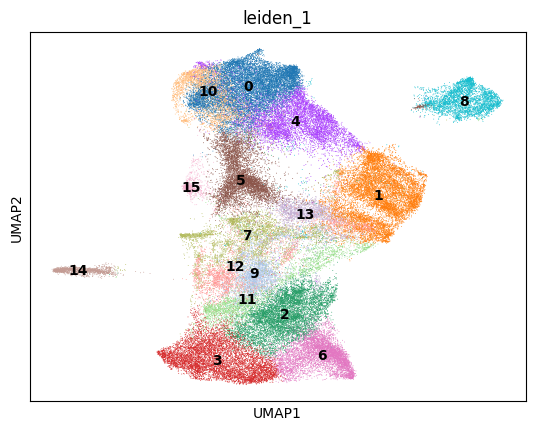

done


In [9]:
resolutions = [0.5, 1]
for resolution in resolutions: 
    print('clustering at resolution '+str(resolution))
    sc.tl.leiden(ad, resolution = resolution, key_added = 'leiden_'+str(resolution))
    sc.pl.umap(ad, color = 'leiden_'+str(resolution), legend_loc = 'on data')
    print("done")

## Plot spatial composition of samples

litt_24h


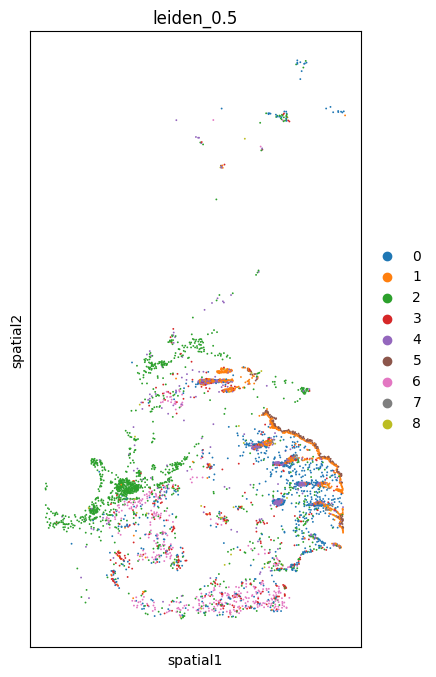

litt_24h


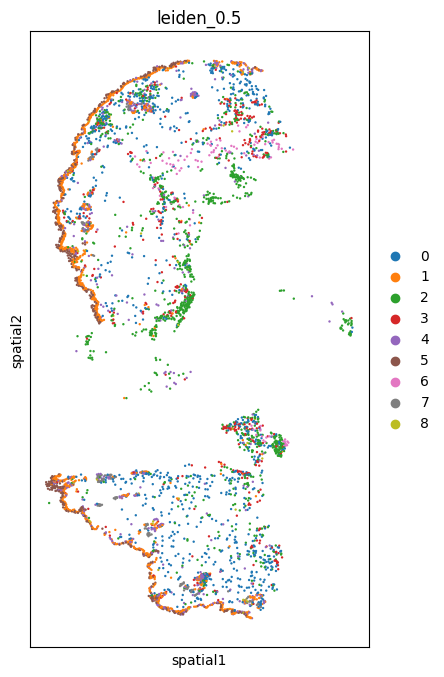

litt_24h


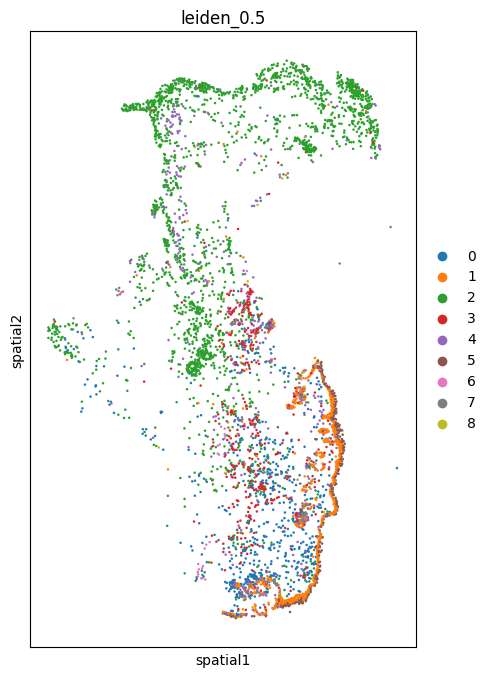

litt_72h


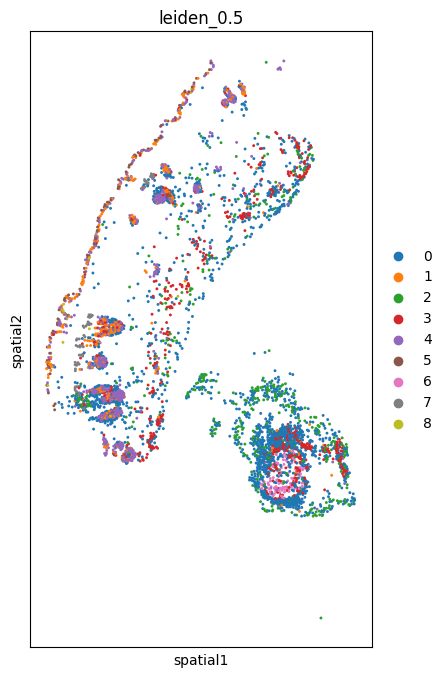

litt_72h


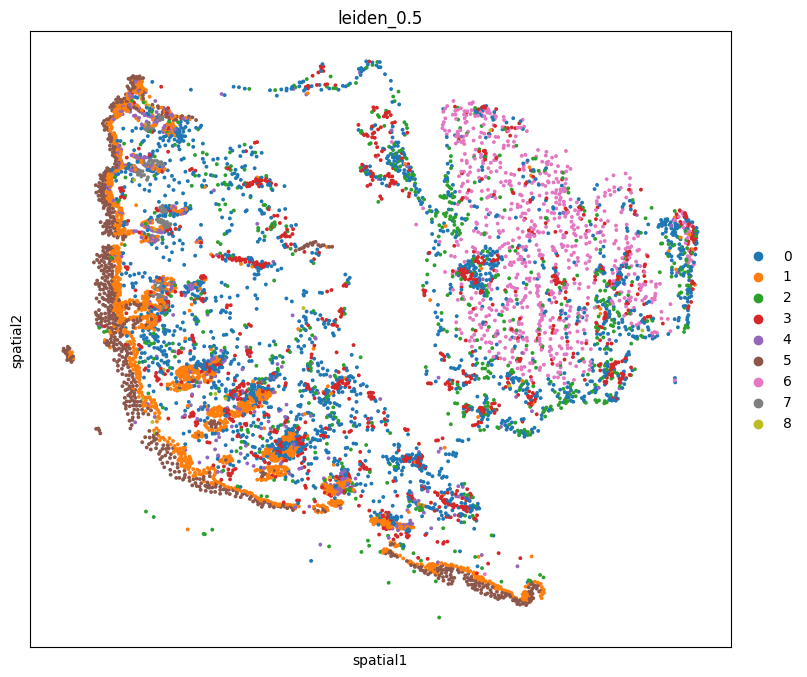

litt_72h


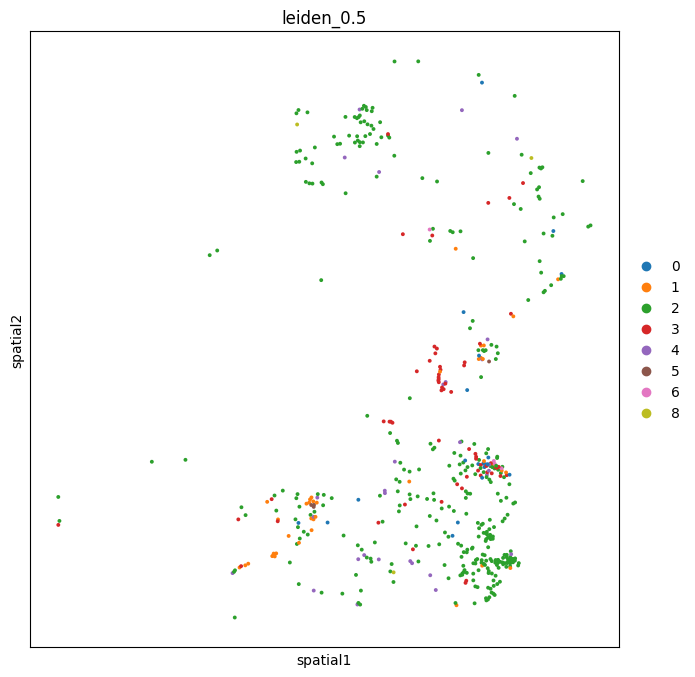

cre_72h


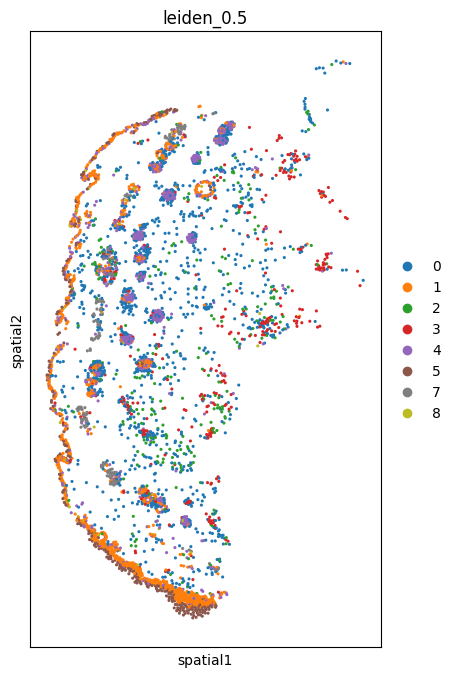

cre_72h


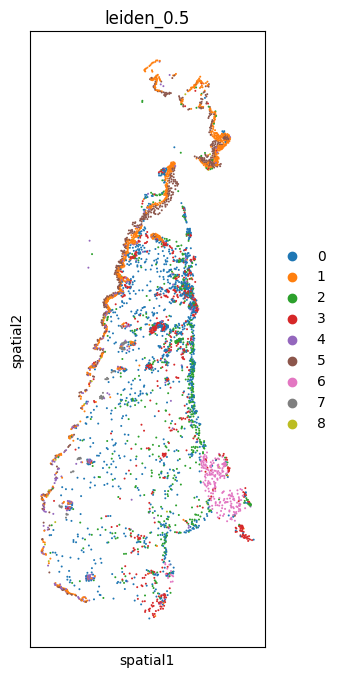

cre_72h


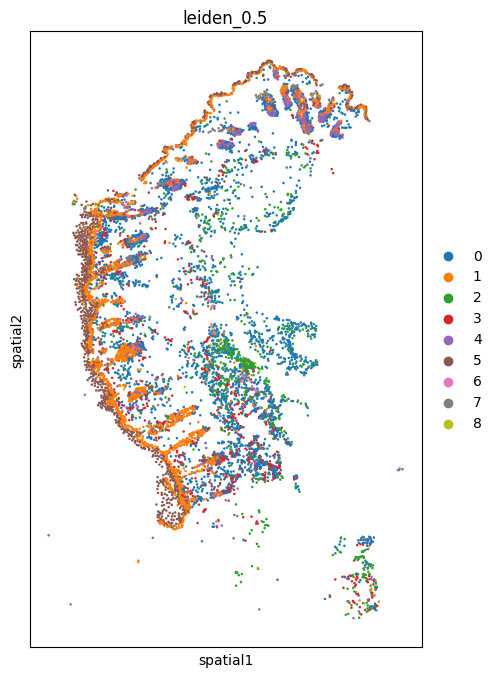

wt_72h


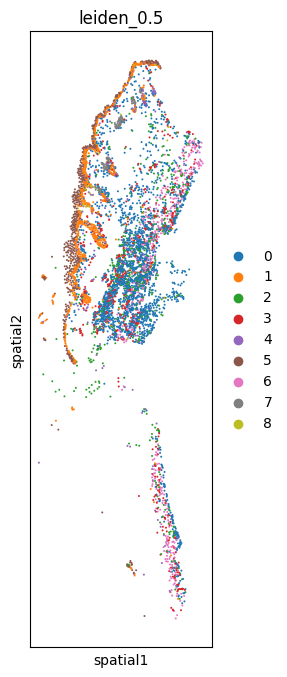

wt_72h


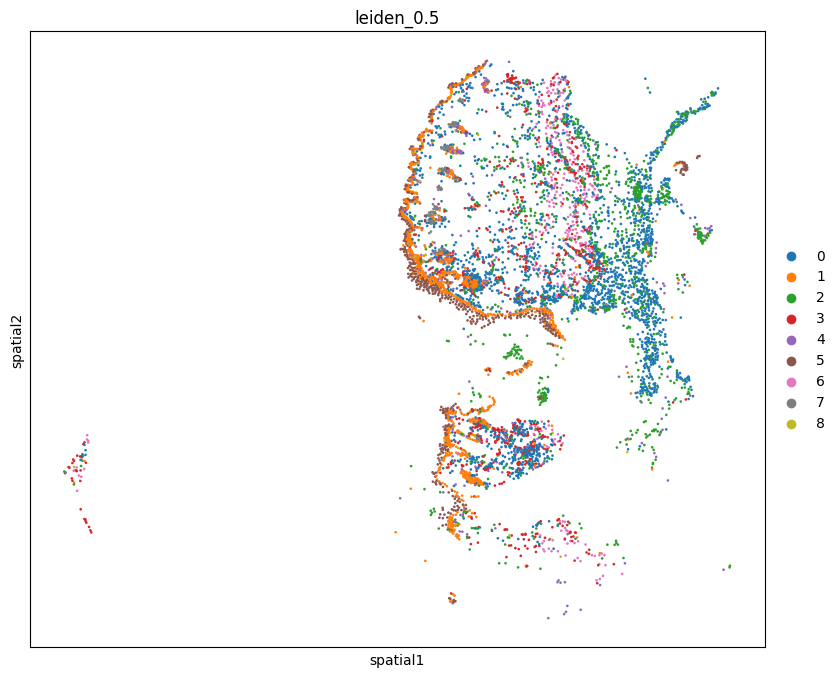

wt_72h


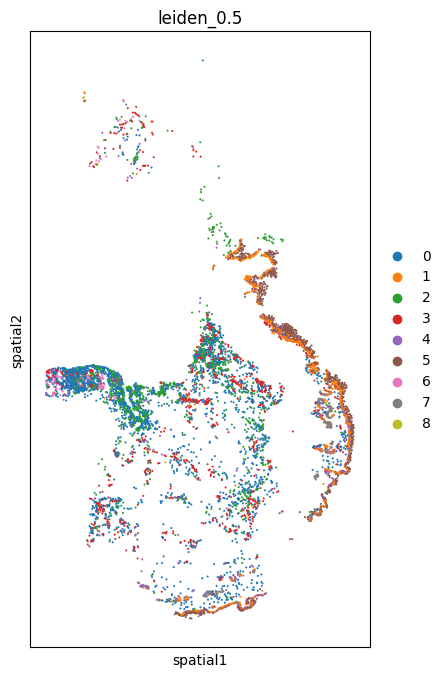

cre_24h


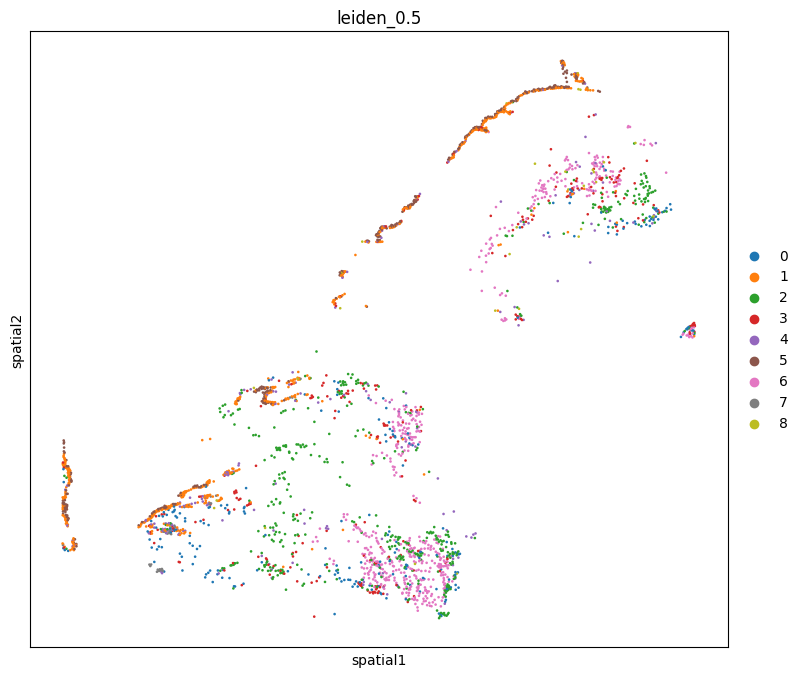

cre_24h


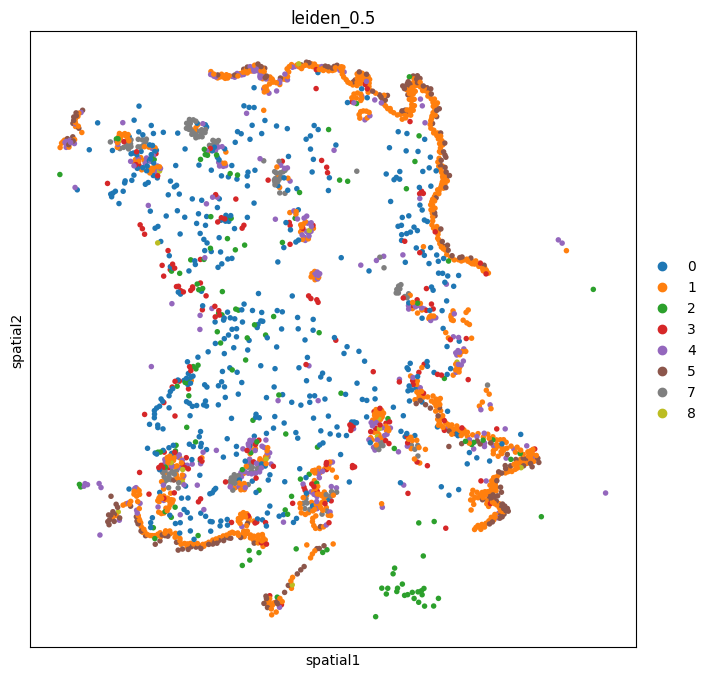

cre_24h


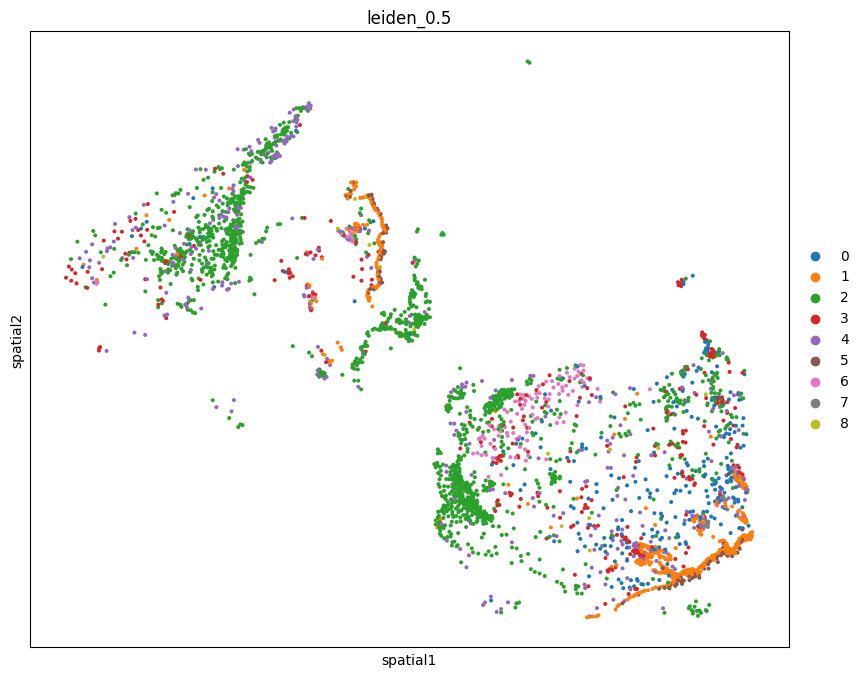

wt_24h


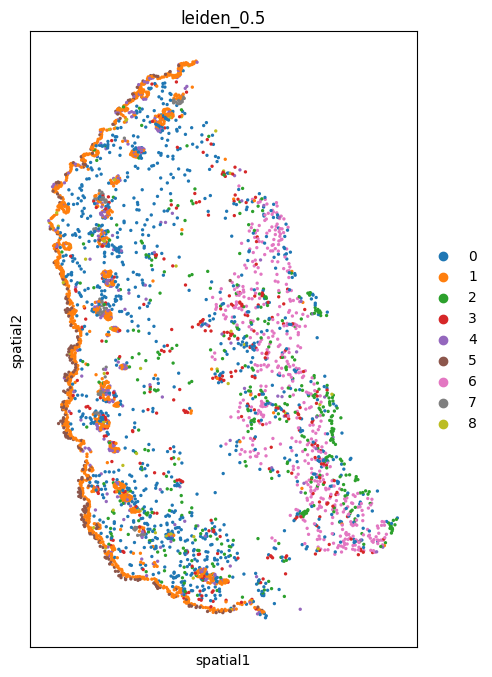

wt_24h


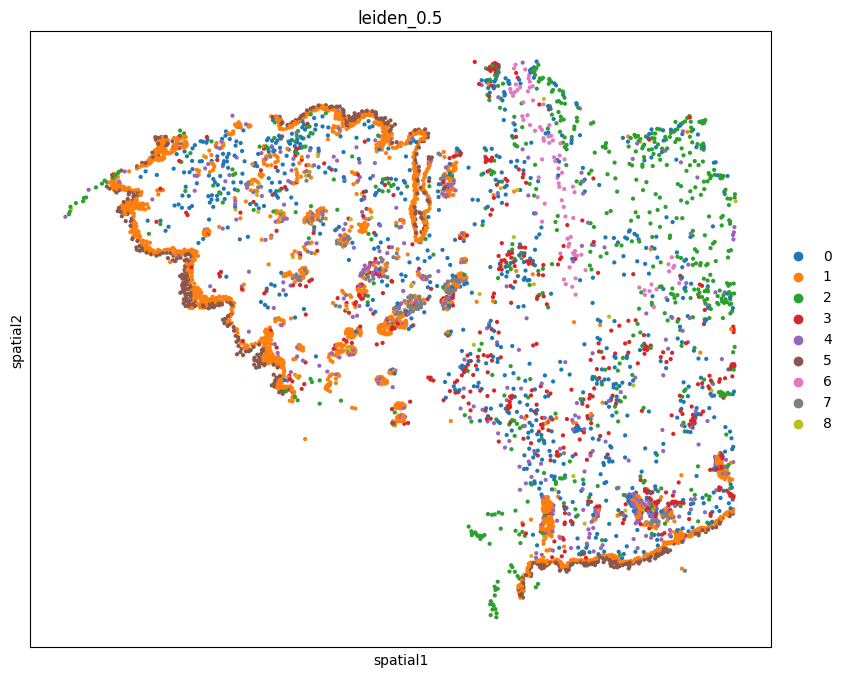

In [10]:
for grid in ad.obs['sample_id'].unique():    
    ad_int = ad[ad.obs['sample_id'] == grid]
    print(ad_int.obs.condition.unique()[0])
    with plt.rc_context({'figure.figsize': (10, 8)}):
        sc.pl.spatial(ad_int, spot_size=15, color = 'leiden_0.5')
    plt.show()


# Main analysis

## Specify comparisions

In [11]:
list(ad.obs.sample_id.unique())

['output-XETG00045__0059976__litt_24h__20250725__091031_1',
 'output-XETG00045__0059976__litt_24h__20250725__091031_2',
 'output-XETG00045__0059976__litt_24h__20250725__091031_0',
 'output-XETG00045__0059976__litt_72h__20250725__091031_1',
 'output-XETG00045__0059976__litt_72h__20250725__091031_2',
 'output-XETG00045__0059976__litt_72h__20250725__091031_0',
 'output-XETG00045__0059976__cre_72h__20250725__091031_2',
 'output-XETG00045__0059976__cre_72h__20250725__091031_1',
 'output-XETG00045__0059976__cre_72h__20250725__091031_0',
 'output-XETG00045__0059976__wt_72h__20250725__091031_2',
 'output-XETG00045__0059976__wt_72h__20250725__091031_1',
 'output-XETG00045__0059976__wt_72h__20250725__091031_0',
 'output-XETG00045__0059976__cre_24h__20250725__091031_0',
 'output-XETG00045__0059976__cre_24h__20250725__091031_1',
 'output-XETG00045__0059976__cre_24h__20250725__091031_2',
 'output-XETG00045__0059976__wt_24h__20250725__091031_1',
 'output-XETG00045__0059976__wt_24h__20250725__091031_

In [12]:
comparisons = {
    # ---------- 24h ----------
    "cre_24h_vs_litt_24h": {
        "case": [
            "output-XETG00045__0059976__cre_24h__20250725__091031"  # samples 1,2,11 collapsed
        ],
        "control": [
            "output-XETG00045__0059976__litt_24h__20250725__091031" # samples 3,4,12 collapsed
        ],
    },
    "cre_24h_vs_wt_24h": {
        "case": [
            "output-XETG00045__0059976__cre_24h__20250725__091031"
        ],
        "control": [
            "output-XETG00045__0059976__wt_24h__20250725__091031"   # samples 5,13 collapsed
        ],
    },
    "litt_24h_vs_wt_24h": {
        "case": [
            "output-XETG00045__0059976__litt_24h__20250725__091031"
        ],
        "control": [
            "output-XETG00045__0059976__wt_24h__20250725__091031"
        ],
    },

    # ---------- 72h ----------
    "cre_72h_vs_litt_72h": {
        "case": [
            "output-XETG00045__0059976__cre_72h__20250725__091031"  # samples 6,8,14 collapsed
        ],
        "control": [
            "output-XETG00045__0059976__litt_72h__20250725__091031" # samples 7,9 collapsed
        ],
    },
    "cre_72h_vs_wt_72h": {
        "case": [
            "output-XETG00045__0059976__cre_72h__20250725__091031"
        ],
        "control": [
            "output-XETG00045__0059976__wt_72h__20250725__091031"   # samples 10,15,16 collapsed
        ],
    },
    "litt_72h_vs_wt_72h": {
        "case": [
            "output-XETG00045__0059976__litt_72h__20250725__091031"
        ],
        "control": [
            "output-XETG00045__0059976__wt_72h__20250725__091031"
        ],
    },
}

In [13]:
# 1) map each file prefix to a condition label
file_to_condition = {
    "output-XETG00045__0059976__litt_24h__20250725__091031": "litt_24h",
    "output-XETG00045__0059976__cre_24h__20250725__091031":  "cre_24h",
    "output-XETG00045__0059976__wt_24h__20250725__091031":   "wt_24h",
    "output-XETG00045__0059976__litt_72h__20250725__091031": "litt_72h",
    "output-XETG00045__0059976__cre_72h__20250725__091031":  "cre_72h",
    "output-XETG00045__0059976__wt_72h__20250725__091031":   "wt_72h",
}

# add condition column (assuming your obs column has the sample_id strings)
ad.obs["condition"] = ad.obs["sample___"].map(file_to_condition)

# 2) define comparisons by condition
comparisons = {
    # ---------- 24h ----------
    "cre_24h_vs_litt_24h": {
        "case":    ["cre_24h"],
        "control": ["litt_24h"],
    },
    "cre_24h_vs_wt_24h": {
        "case":    ["cre_24h"],
        "control": ["wt_24h"],
    },
    "litt_24h_vs_wt_24h": {
        "case":    ["litt_24h"],
        "control": ["wt_24h"],
    },

    # ---------- 72h ----------
    "cre_72h_vs_litt_72h": {
        "case":    ["cre_72h"],
        "control": ["litt_72h"],
    },
    "cre_72h_vs_wt_72h": {
        "case":    ["cre_72h"],
        "control": ["wt_72h"],
    },
    "litt_72h_vs_wt_72h": {
        "case":    ["litt_72h"],
        "control": ["wt_72h"],
    },
}

In [14]:
import pandas as pd

COND_COL = "condition"
SAMPLE_COL = "sample_id"

# 1) Counts of UNIQUE samples per condition
sample_counts = ad.obs.groupby(COND_COL)[SAMPLE_COL].nunique().sort_values(ascending=False)
print("Unique samples per condition:\n", sample_counts)

# 2) List sample IDs per condition
cond_to_samples = (
    ad.obs.groupby(COND_COL)[SAMPLE_COL]
      .apply(lambda s: sorted(s.unique().tolist()))
      .to_dict()
)
print("\nSample IDs per condition:")
for cond, sids in cond_to_samples.items():
    print(f"- {cond} ({len(sids)}): {sids}")

def expand_comparisons_to_samples(comparisons, cond_to_samples):
    """Return dict mapping comparison -> {'case_samples': [...], 'control_samples': [...]}."""
    out = {}
    for name, spec in comparisons.items():
        case_conditions = spec["case"]
        ctrl_conditions = spec["control"]
        # Gather sample IDs for each side, keeping order stable
        case_samples = sum([cond_to_samples.get(c, []) for c in case_conditions], [])
        ctrl_samples = sum([cond_to_samples.get(c, []) for c in ctrl_conditions], [])
        # Sanity checks
        overlap = set(case_samples) & set(ctrl_samples)
        if overlap:
            print(f"[WARN] Overlapping samples in {name}: {sorted(overlap)}")
        if len(case_samples) == 0 or len(ctrl_samples) == 0:
            print(f"[WARN] Empty group in {name}: case={len(case_samples)}, control={len(ctrl_samples)}")

        out[name] = {"case_samples": case_samples, "control_samples": ctrl_samples}
    return out

expanded = expand_comparisons_to_samples(comparisons, cond_to_samples)

print("\nExpanded comparisons (per-sample):")
for name, groups in expanded.items():
    print(f"\n{name}")
    print(f"  case    ({len(groups['case_samples'])}):    {groups['case_samples']}")
    print(f"  control ({len(groups['control_samples'])}): {groups['control_samples']}")

Unique samples per condition:
 condition
cre_24h     3
cre_72h     3
litt_24h    3
litt_72h    3
wt_72h      3
wt_24h      2
Name: sample_id, dtype: int64

Sample IDs per condition:
- cre_24h (3): ['output-XETG00045__0059976__cre_24h__20250725__091031_0', 'output-XETG00045__0059976__cre_24h__20250725__091031_1', 'output-XETG00045__0059976__cre_24h__20250725__091031_2']
- cre_72h (3): ['output-XETG00045__0059976__cre_72h__20250725__091031_0', 'output-XETG00045__0059976__cre_72h__20250725__091031_1', 'output-XETG00045__0059976__cre_72h__20250725__091031_2']
- litt_24h (3): ['output-XETG00045__0059976__litt_24h__20250725__091031_0', 'output-XETG00045__0059976__litt_24h__20250725__091031_1', 'output-XETG00045__0059976__litt_24h__20250725__091031_2']
- litt_72h (3): ['output-XETG00045__0059976__litt_72h__20250725__091031_0', 'output-XETG00045__0059976__litt_72h__20250725__091031_1', 'output-XETG00045__0059976__litt_72h__20250725__091031_2']
- wt_24h (2): ['output-XETG00045__0059976__wt_24h_

## Save transformed data 

In [15]:
ad.layers['transformed'] = ad.X.copy()

In [16]:
ad.X = ad.layers['counts']

In [17]:
ad.X.max()

211.0

## Pseudobulking and differential gene expression

In [18]:
# =========================
# PSEUDOBULK + DE (from scratch)
# =========================
import numpy as np, pandas as pd
from scipy import sparse, stats
from statsmodels.stats.multitest import multipletests

# ---------- USER CONFIG ----------
COND_COL       = "condition"   # ad.obs column with condition labels
SAMPLE_COL     = "sample_id"   # ad.obs column with sample identifiers (replicates)
CELLTYPE_COL   = None          # e.g. "cell_type" to stratify; or None to pool all cells
MIN_TOTAL_COUNTS = 10          # prefilter genes: total pseudobulk counts across all samples >= this
PRIOR_COUNT      = 1.0         # logCPM prior
FDR_ALPHA        = 0.05


# ---------- HELPERS ----------
def get_counts_and_genes(adata):
    """
    Returns (X, genes) where X is cells×genes counts and 'genes' matches X.
    Priority: layers['raw'] > layers['counts'] > ad.raw.X
    """
    if "raw" in adata.layers:
        X = adata.layers["raw"]
        genes = adata.var_names
    elif "counts" in adata.layers:
        X = adata.layers["counts"]
        genes = adata.var_names
    elif adata.raw is not None:
        X = adata.raw.X
        genes = adata.raw.var_names
    else:
        raise ValueError("No counts found. Expected ad.layers['raw'] or ['counts'] or ad.raw.X.")
    return X, pd.Index(genes)

def logcpm(counts, lib_sizes=None, prior_count=1.0, scale=1e6):
    """
    Log2-CPM with prior (edgeR-style).
    counts: genes×samples dense array
    """
    if lib_sizes is None:
        lib_sizes = counts.sum(axis=0)
    lib_sizes = np.asarray(lib_sizes, dtype=float).reshape(1, -1)
    cpm = (counts * scale) / np.maximum(lib_sizes, 1.0)
    return np.log2(cpm + prior_count)

def sanitize_pvals(p):
    """Replace NaN/Inf with 1, clip into (tiny,1]."""
    p = np.asarray(p, dtype=float)
    p[~np.isfinite(p)] = 1.0
    return np.clip(p, np.finfo(float).tiny, 1.0)

# ---------- CORE: PSEUDOBULK ----------
def pseudobulk_by_sample(adata, celltype_col=None):
    """
    Returns:
      pb_counts: DataFrame [genes × samples]
      sample_meta: DataFrame with columns [group_key, sample_id, condition, (celltype?)]
    """
    X, genes = get_counts_and_genes(adata)  # cells×genes
    X = X.tocsr() if sparse.issparse(X) else np.asarray(X)

    cols = [SAMPLE_COL, COND_COL] + ([celltype_col] if celltype_col else [])
    obs = adata.obs[cols].copy()

    group_key_cols = [SAMPLE_COL] + ([celltype_col] if celltype_col else [])
    key_df = obs[group_key_cols].astype(str)
    key_df["_grp"] = key_df.apply(lambda r: "||".join(r.values.tolist()), axis=1)
    groups, inv = np.unique(key_df["_grp"].values, return_inverse=True)

    G = len(groups)
    pb = np.zeros((X.shape[1], G), dtype=np.float64)  # genes×groups
    for g in range(G):
        idx = np.where(inv == g)[0]
        if len(idx) == 0:
            continue
        if sparse.issparse(X):
            pb[:, g] = X[idx, :].sum(axis=0).A1
        else:
            pb[:, g] = X[idx, :].sum(axis=0)

    # Build sample metadata (and map condition per sample_id)
    meta_parts = [g.split("||") for g in groups]
    meta_cols = [SAMPLE_COL] + ([celltype_col] if celltype_col else [])
    sample_meta = pd.DataFrame(meta_parts, columns=meta_cols)

    cond_map = (obs.groupby(SAMPLE_COL)[COND_COL]
                  .agg(lambda s: s.unique()[0] if s.nunique()==1 else s.mode().iloc[0])
                  .to_dict())
    sample_meta[COND_COL] = sample_meta[SAMPLE_COL].map(cond_map)

    colnames = [
        f"{r[SAMPLE_COL]}" + (f"|{r[celltype_col]}" if celltype_col else "")
        for _, r in sample_meta.iterrows()
    ]
    pb_counts = pd.DataFrame(pb, index=genes, columns=colnames)
    sample_meta["group_key"] = colnames

    # Drop any all-zero columns (rare but safe)
    keep_cols = pb_counts.sum(axis=0) > 0
    if (~keep_cols).any():
        pb_counts = pb_counts.loc[:, keep_cols.values]
        sample_meta = sample_meta.loc[keep_cols.values].reset_index(drop=True)

    return pb_counts, sample_meta

# ---------- CORE: DE ----------
def run_de_welch_logcpm(logcpm_mat, sample_meta, case_conditions, ctrl_conditions):
    """
    Welch's t-test on logCPM for case vs control.
    Returns a tidy DE DataFrame indexed by gene.
    """
    sel_case = sample_meta[sample_meta[COND_COL].isin(case_conditions)]["group_key"].tolist()
    sel_ctrl = sample_meta[sample_meta[COND_COL].isin(ctrl_conditions)]["group_key"].tolist()
    n_case, n_ctrl = len(sel_case), len(sel_ctrl)
    if n_case < 2 or n_ctrl < 2:
        print(f"[WARN] Low replicate counts: case={n_case}, control={n_ctrl}. Stats will be weak.")

    Xc = logcpm_mat[sel_case].to_numpy()  # genes×n_case
    Xn = logcpm_mat[sel_ctrl].to_numpy()  # genes×n_ctrl

    mean_case = Xc.mean(axis=1)
    mean_ctrl = Xn.mean(axis=1)
    log2fc = mean_case - mean_ctrl

    t_stat, pvals = stats.ttest_ind(Xc, Xn, equal_var=False, axis=1, nan_policy="omit")
    pvals = sanitize_pvals(pvals)
    padj = multipletests(pvals, method="fdr_bh")[1]

    de = pd.DataFrame({
        "gene": logcpm_mat.index.values,
        "log2fc": log2fc,
        "pval": pvals,
        "padj": padj,
        "mean_logCPM_case": mean_case,
        "mean_logCPM_ctrl": mean_ctrl,
        "n_case_samples": n_case,
        "n_ctrl_samples": n_ctrl,
        "mode": "pseudobulk_mean",
    }).set_index("gene").sort_values(["padj","pval","log2fc"], ascending=[True,True,False])

    return de

# ---------- DRIVER ----------
def run_pseudobulk_de(adata, comparisons, celltype_col=None,
                      min_total_counts=MIN_TOTAL_COUNTS, prior_count=PRIOR_COUNT, alpha=FDR_ALPHA):
    # 1) pseudobulk
    pb_counts, sample_meta = pseudobulk_by_sample(adata, celltype_col=celltype_col)

    # 2) crude prefilter BEFORE logCPM
    if min_total_counts is not None and min_total_counts > 0:
        keep = (pb_counts.sum(axis=1) >= min_total_counts)
        pb_counts = pb_counts.loc[keep]

    # 3) logCPM
    lib_sizes = pb_counts.sum(axis=0).values
    logcpm_mat = pd.DataFrame(
        logcpm(pb_counts.values, lib_sizes=lib_sizes, prior_count=prior_count, scale=1e6),
        index=pb_counts.index, columns=pb_counts.columns
    )

    # 4) DE per comparison
    results = {}
    for name, spec in comparisons.items():
        de = run_de_welch_logcpm(logcpm_mat, sample_meta, spec["case"], spec["control"])
        results[name] = de
        # quick summary
        sig = (de["padj"] <= alpha).sum()
        print(f"\n=== {name} ===")
        print(f"tested genes: {de.shape[0]} | significant @ FDR≤{alpha}: {sig}")
        print(de.head(10)[["log2fc","pval","padj","n_case_samples","n_ctrl_samples"]])

    return results, pb_counts, sample_meta, logcpm_mat

# ----------------- RUN -----------------
results, pb_counts, sample_meta, logcpm_mat = run_pseudobulk_de(
    ad, comparisons, celltype_col=CELLTYPE_COL,
    min_total_counts=MIN_TOTAL_COUNTS, prior_count=PRIOR_COUNT, alpha=FDR_ALPHA
)

# Example: access and save one result
# name = "Pdl1_wt+C57_vs_Pdl1_cre"
# results[name].to_csv(f"{name}__pseudobulk_DE.csv")


=== cre_24h_vs_litt_24h ===
tested genes: 4956 | significant @ FDR≤0.05: 0
          log2fc      pval      padj  n_case_samples  n_ctrl_samples
gene                                                                
Kcnab2 -1.666700  0.000911  0.997229               3               3
Cth     1.338184  0.001069  0.997229               3               3
Prkd3  -0.545011  0.003964  0.997229               3               3
Strn3  -0.705748  0.004717  0.997229               3               3
Igll1   2.071938  0.004756  0.997229               3               3
Polb   -0.781472  0.005106  0.997229               3               3
Ero1lb -0.920174  0.005839  0.997229               3               3
Polk   -0.540377  0.008942  0.997229               3               3
Ldlr    0.735759  0.009298  0.997229               3               3
Ptpn23  0.298163  0.010056  0.997229               3               3

=== cre_24h_vs_wt_24h ===
tested genes: 4956 | significant @ FDR≤0.05: 0
         log2fc      p

In [19]:
combined_results = pd.concat(results, names=["comparison"])
combined_results = combined_results.reset_index(level="comparison").reset_index()

In [25]:
combined_results

,comparison,log2fc,pval,padj,mean_logCPM_case,mean_logCPM_ctrl,n_case_samples,n_ctrl_samples,mode
0,cre_24h_vs_litt_24h,-1.666700,0.000911,0.997229,3.430671,5.097371,3,3,pseudobulk_mean
1,cre_24h_vs_litt_24h,1.338184,0.001069,0.997229,6.716119,5.377935,3,3,pseudobulk_mean
2,cre_24h_vs_litt_24h,-0.545011,0.003964,0.997229,6.940096,7.485107,3,3,pseudobulk_mean
3,cre_24h_vs_litt_24h,-0.705748,0.004717,0.997229,6.734107,7.439855,3,3,pseudobulk_mean
4,cre_24h_vs_litt_24h,2.071938,0.004756,0.997229,3.918486,1.846547,3,3,pseudobulk_mean
...,...,...,...,...,...,...,...,...,...
29731,litt_72h_vs_wt_72h,0.000000,1.000000,1.000000,0.000000,0.000000,3,3,pseudobulk_mean
29732,litt_72h_vs_wt_72h,0.000000,1.000000,1.000000,0.000000,0.000000,3,3,pseudobulk_mean
29733,litt_72h_vs_wt_72h,0.000000,1.000000,1.000000,0.000000,0.000000,3,3,pseudobulk_mean
29734,litt_72h_vs_wt_72h,0.000000,1.000000,1.000000,0.000000,0.000000,3,3,pseudobulk_mean


## Export data for customer

In [26]:
combined_results.to_csv('../../results/differential-gene-expression/skin_grafts_pseudobulk_comparision.csv')

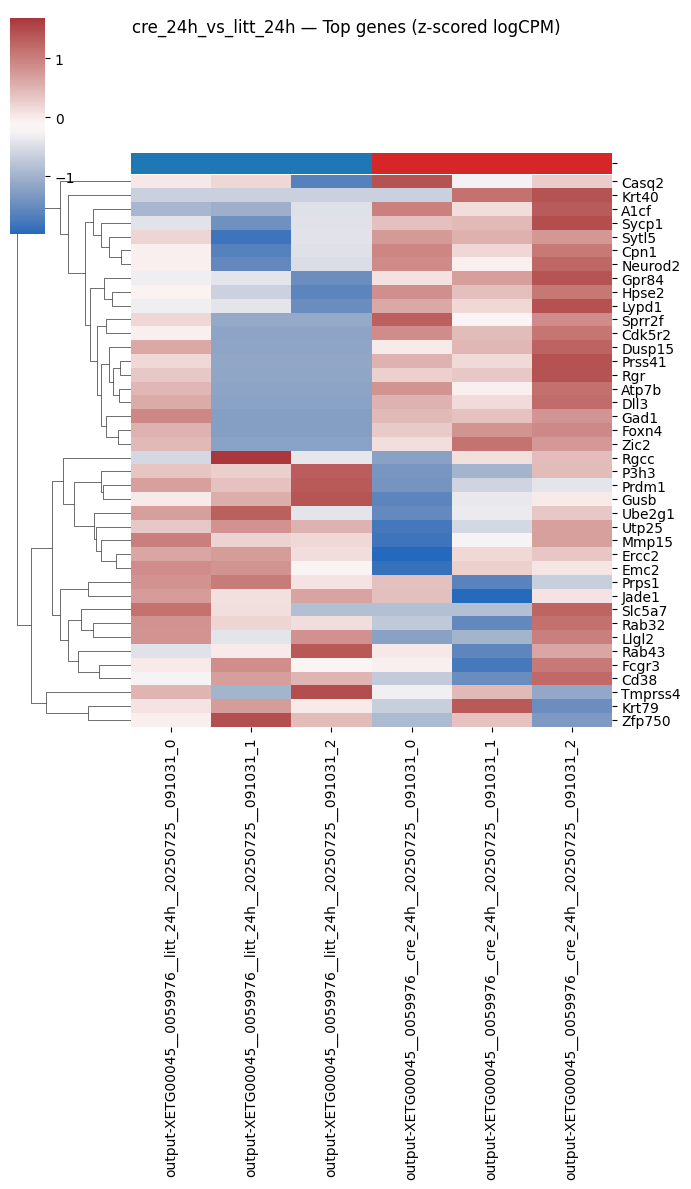

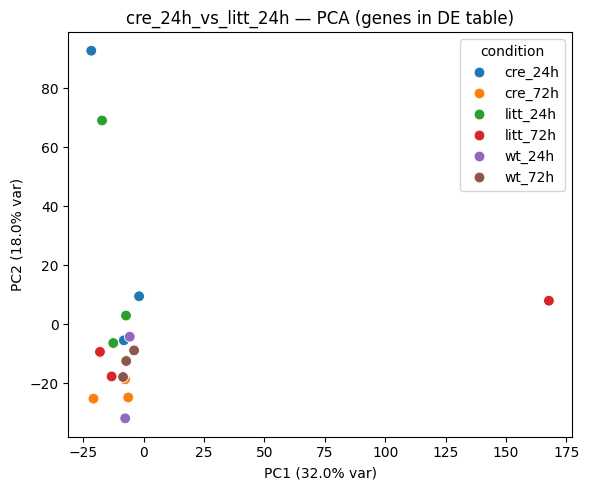

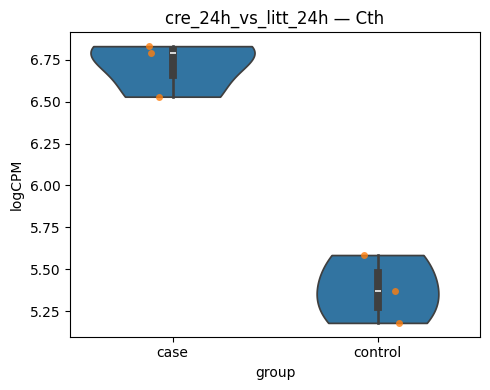

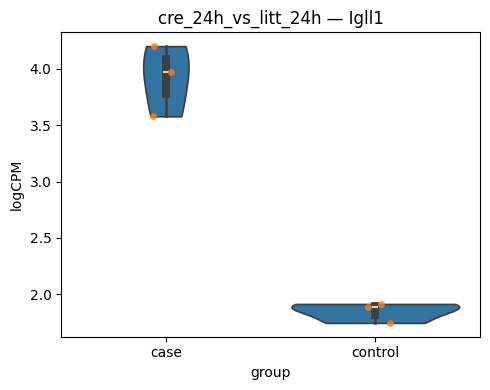

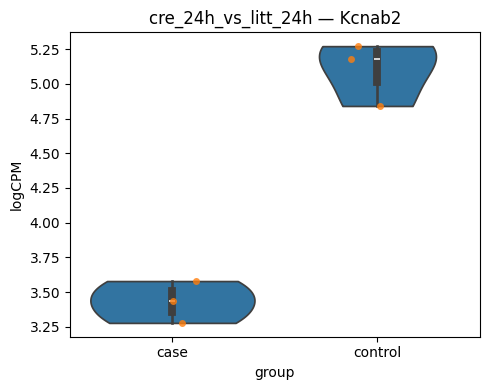

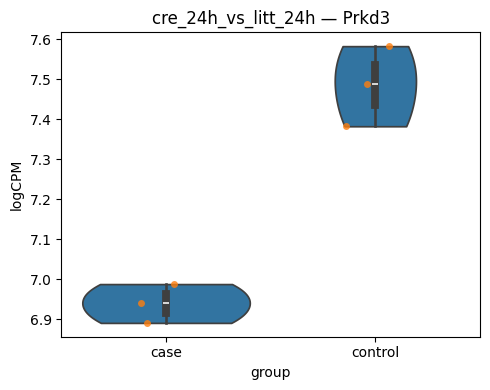

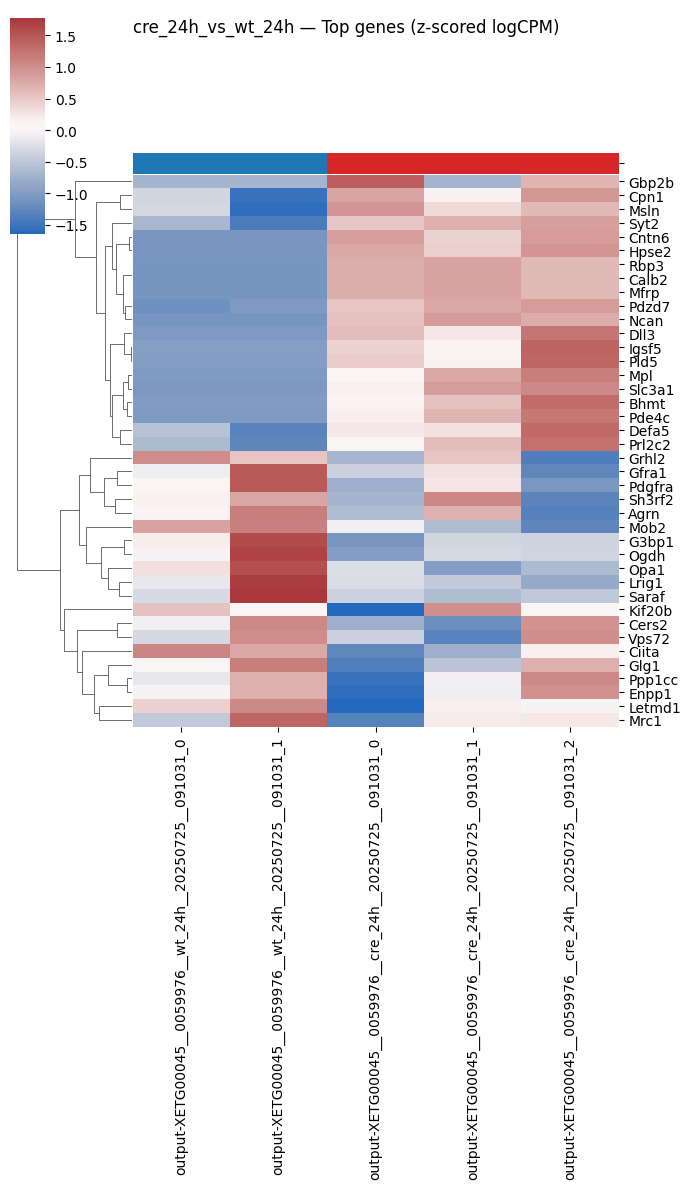

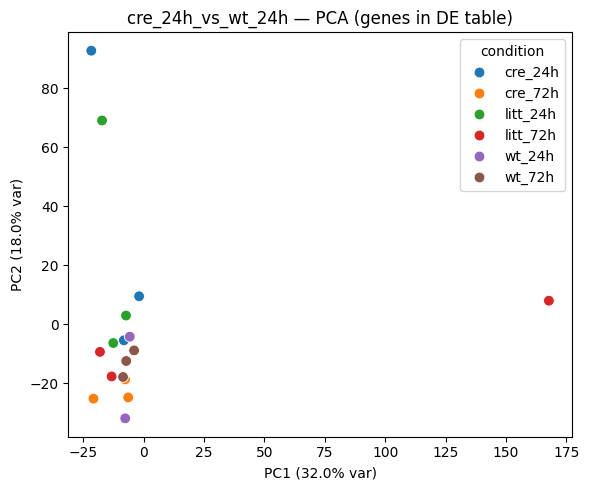

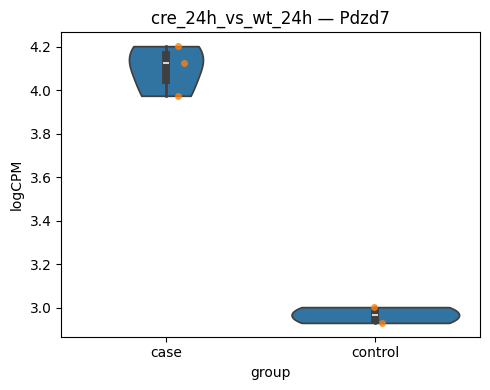

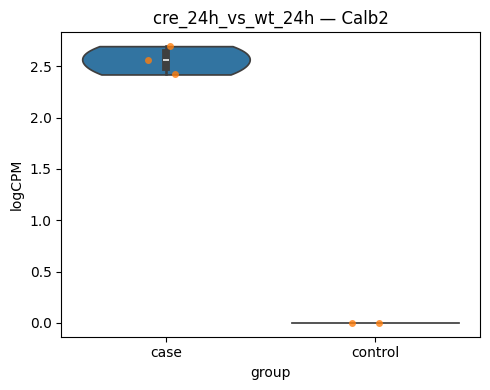

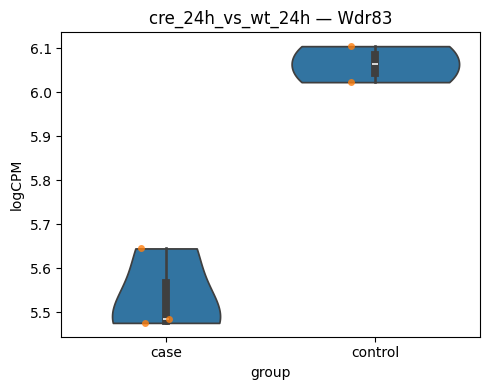

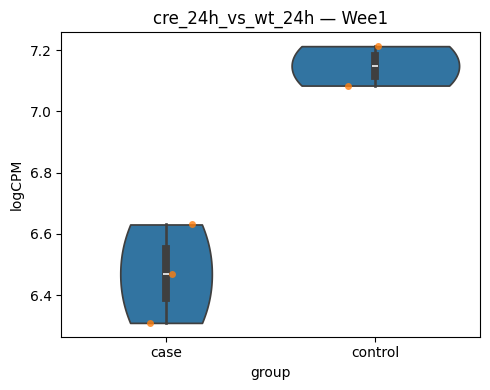

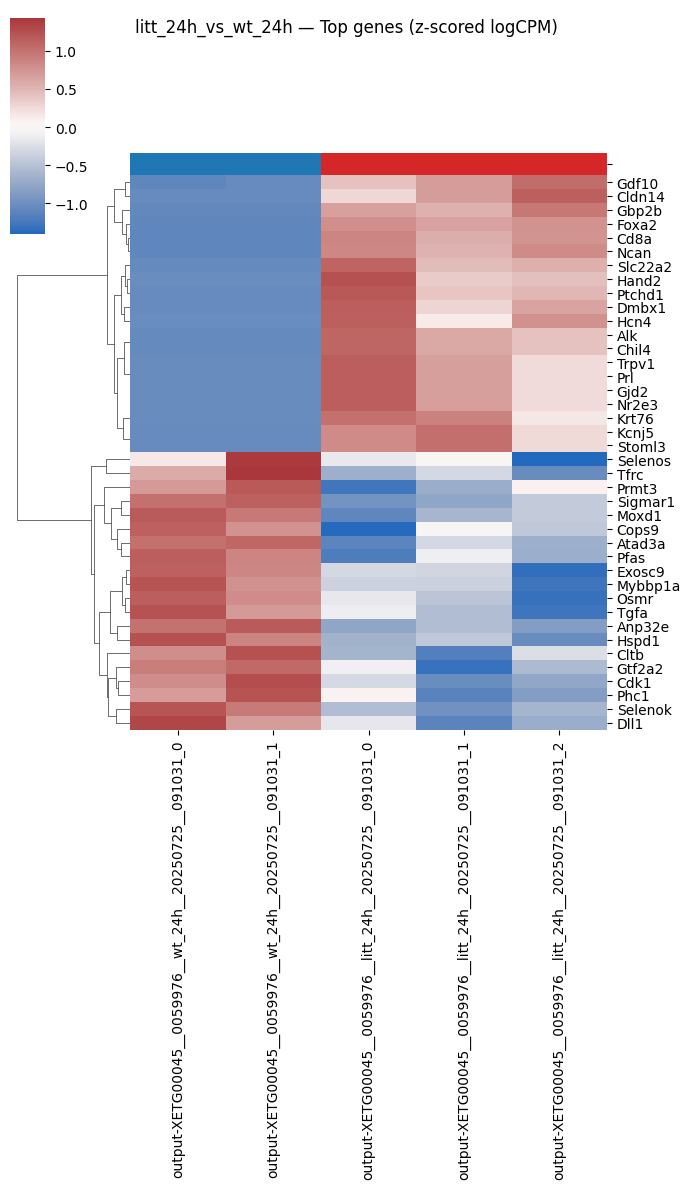

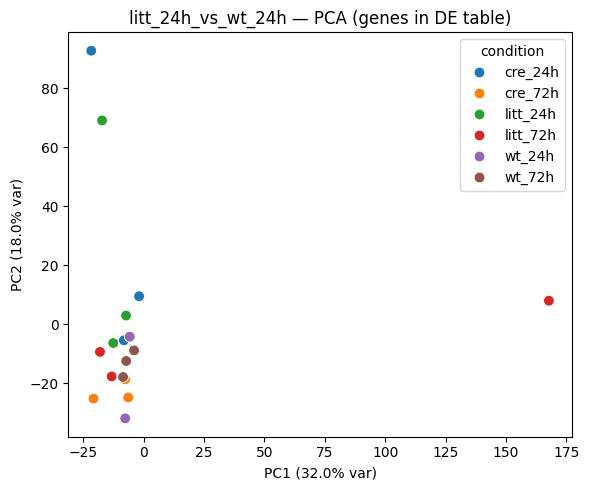

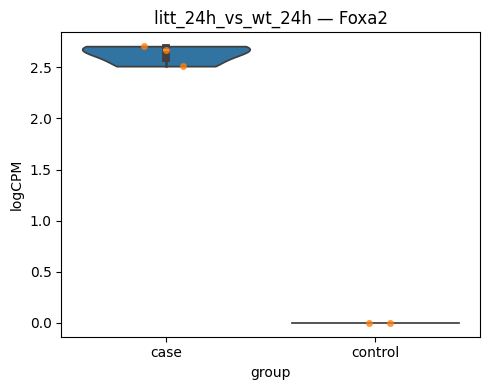

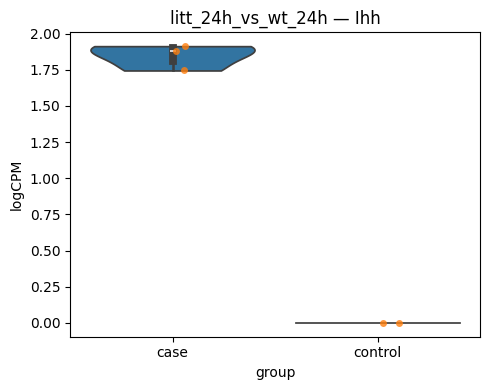

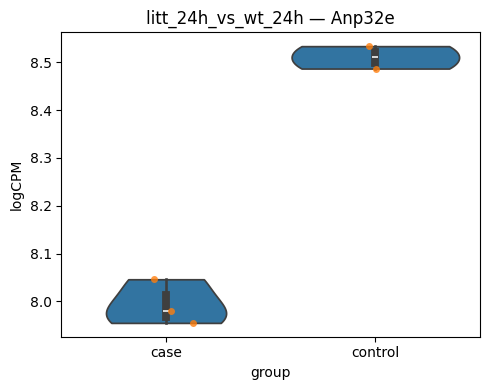

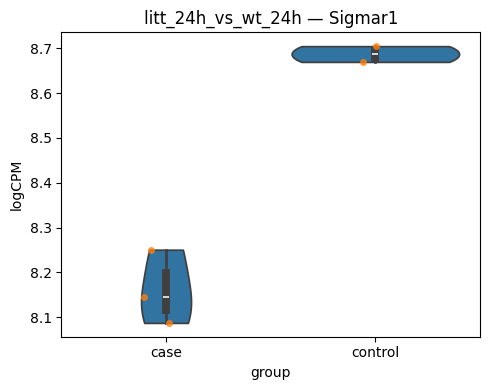

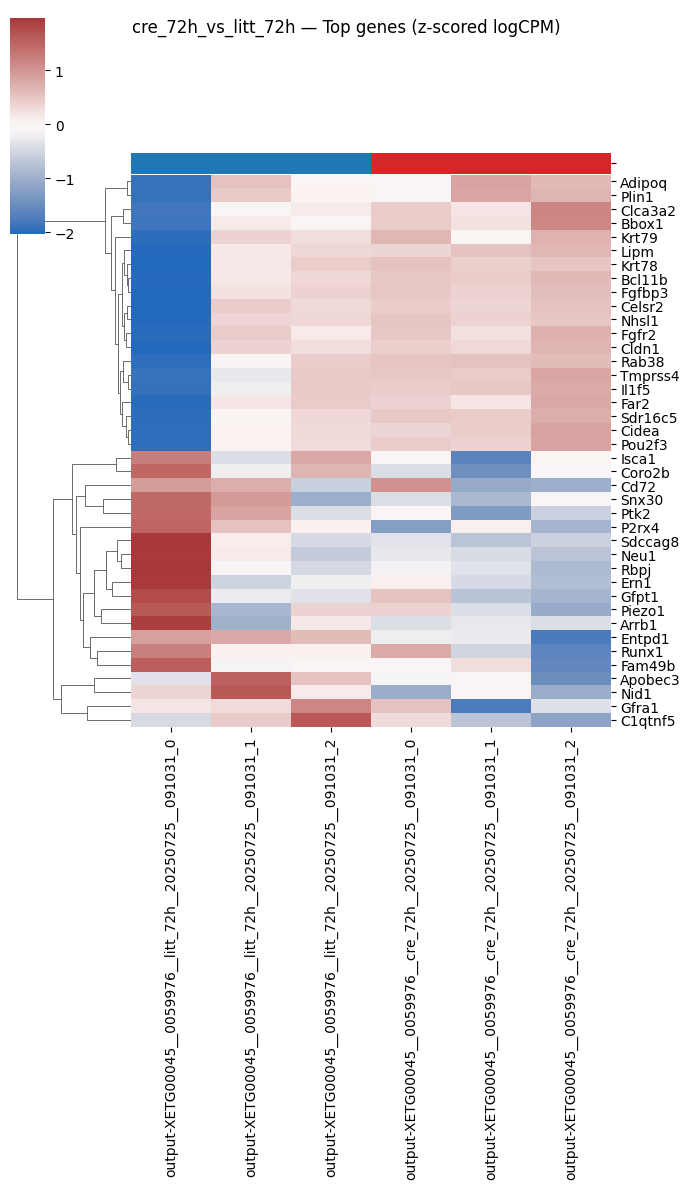

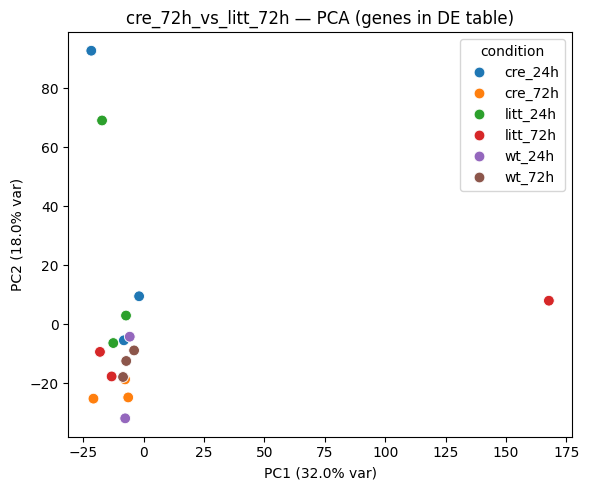

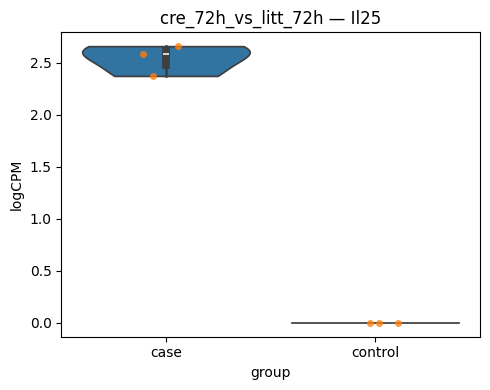

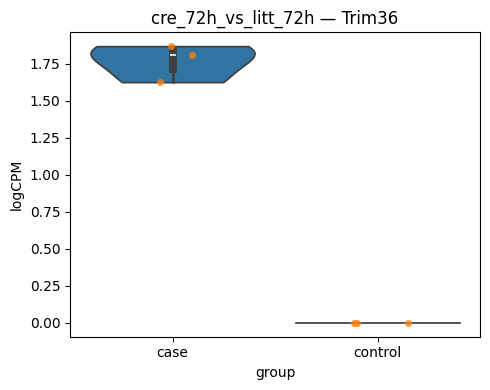

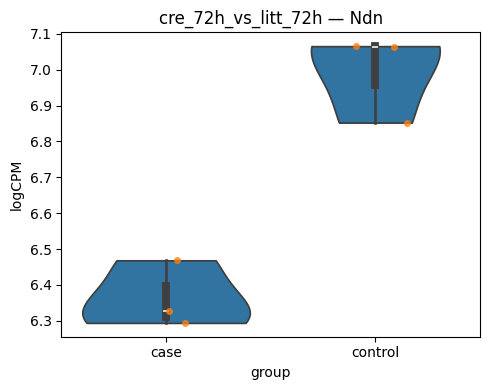

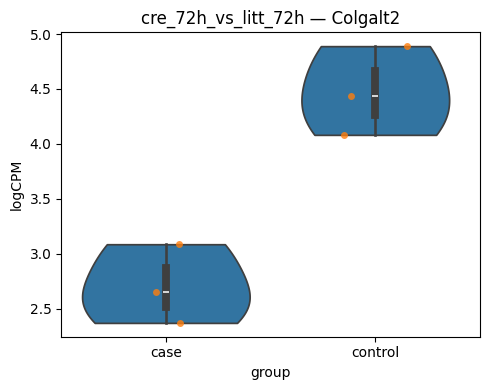

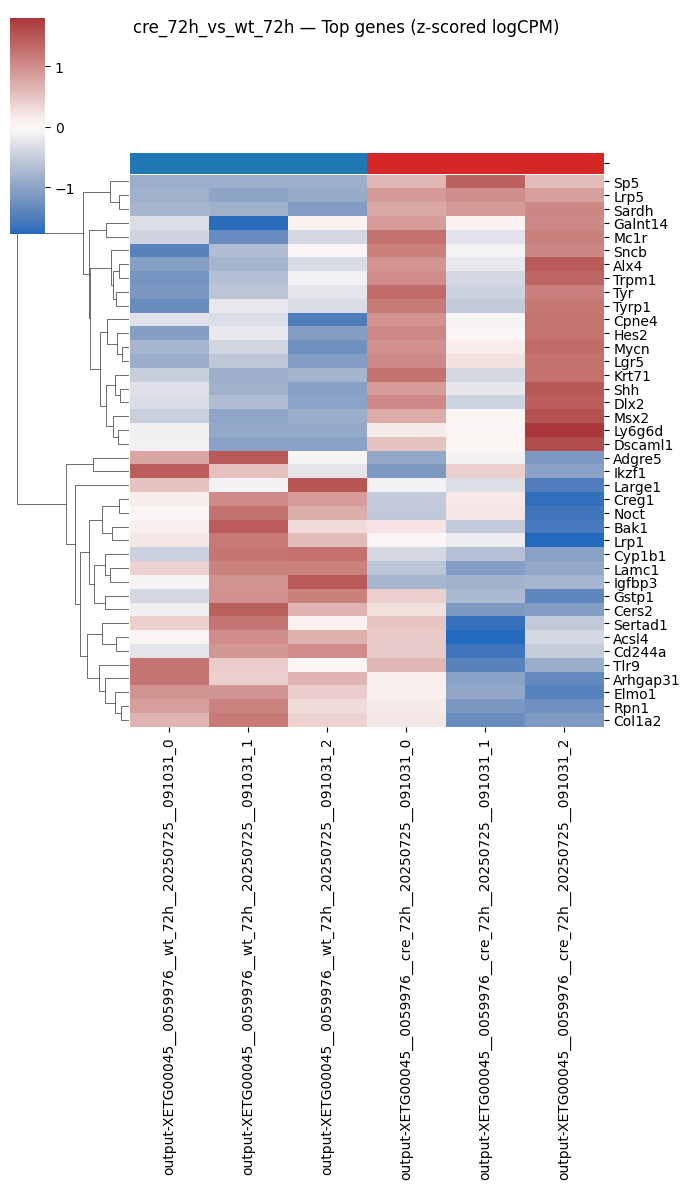

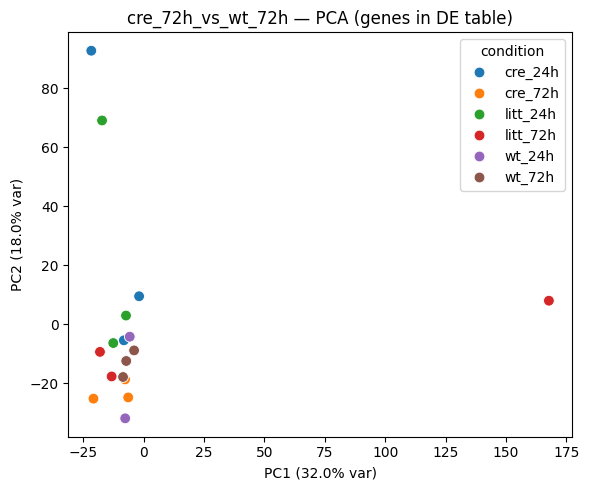

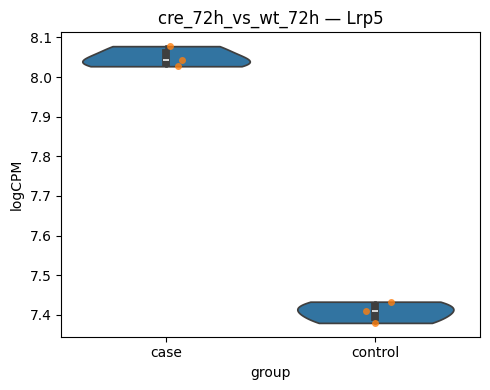

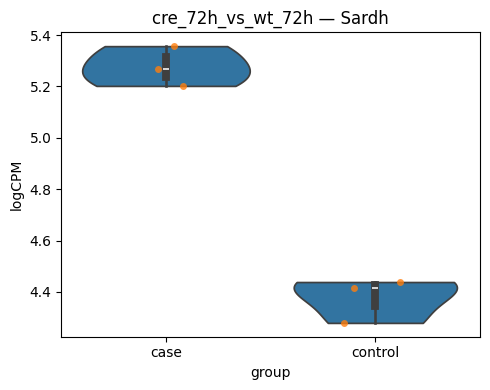

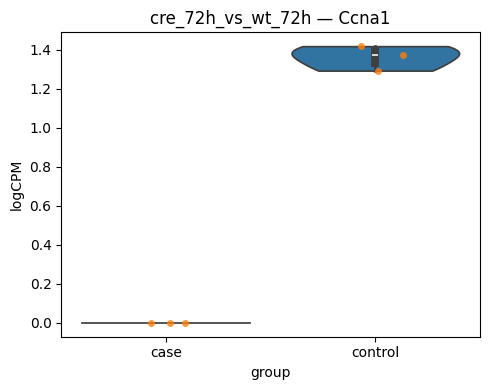

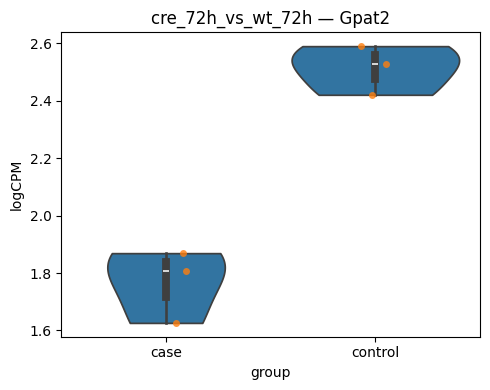

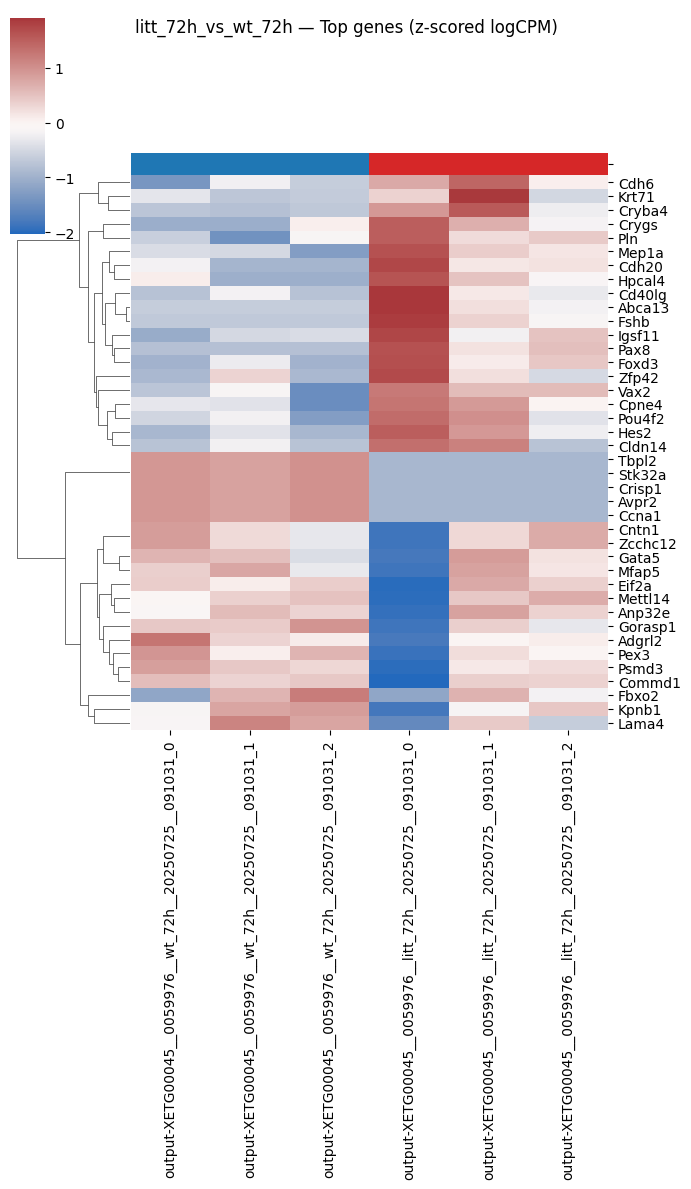

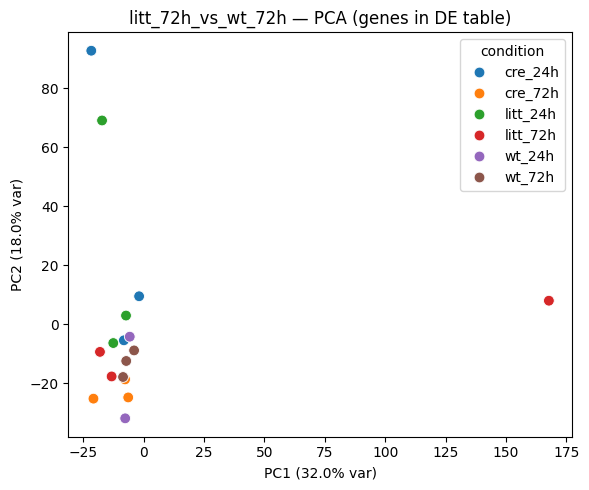

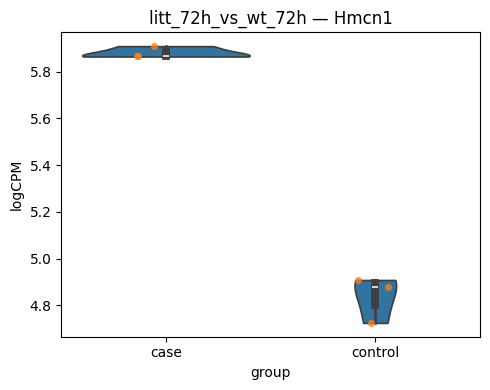

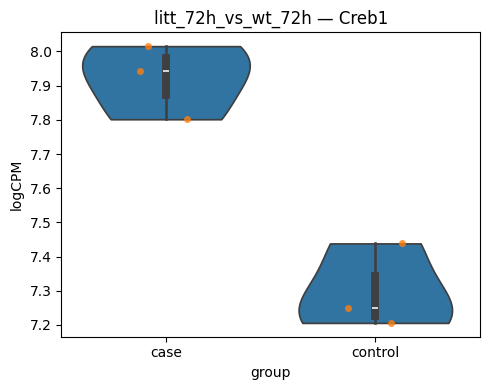

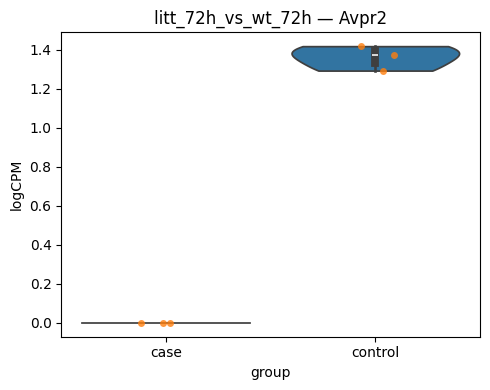

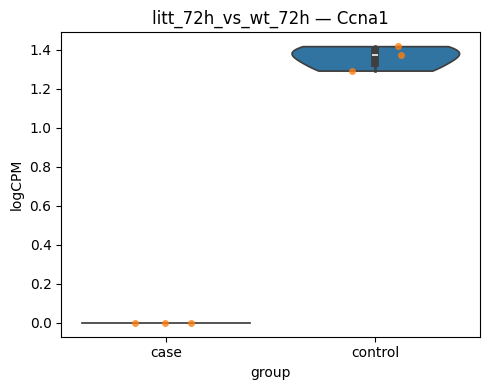

In [27]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# ---------- CONFIG ----------
FDR_THR  = 1
LFC_THR  = 0.5
TOP_N    = 20
FIGSIZE  = (6,5)

def _sig_mask(df, fdr_thr=FDR_THR, lfc_thr=LFC_THR):
    return (df["padj"] <= fdr_thr) & (df["log2fc"].abs() >= lfc_thr)

# ---------- VOLCANO ----------
def plot_volcano(de, title="", fdr_thr=FDR_THR, lfc_thr=LFC_THR, top_n=TOP_N, annotate=True):
    df = de.copy()
    # Handle filtered genes (padj NaN) by setting for plotting only
    df["padj_plot"] = df["padj"].fillna(1.0)
    df["neglog10_padj"] = -np.log10(df["padj_plot"].clip(lower=1e-300))

    sig = (df["padj_plot"] <= fdr_thr) & (df["log2fc"].abs() >= lfc_thr)

    plt.figure(figsize=FIGSIZE)
    plt.scatter(df.loc[~sig, "log2fc"], df.loc[~sig, "neglog10_padj"], s=8, alpha=0.4)
    plt.scatter(df.loc[sig,  "log2fc"], df.loc[sig,  "neglog10_padj"], s=10, alpha=0.85)

    plt.axvline(+lfc_thr, ls="--", lw=1, color="grey")
    plt.axvline(-lfc_thr, ls="--", lw=1, color="grey")
    plt.axhline(-np.log10(fdr_thr), ls="--", lw=1, color="grey")

    plt.xlabel("log2FC (case vs control)")
    plt.ylabel("-log10(FDR)")
    plt.title(title or "Volcano")

    if annotate:
        # label significant if any; else label top_n by raw p
        if sig.any():
            lab = df[sig].nsmallest(top_n, "padj_plot")
        else:
            lab = df.nsmallest(top_n, "pval")
        for g, r in lab.iterrows():
            plt.text(r["log2fc"], r["neglog10_padj"], g, fontsize=7, ha="left", va="bottom", alpha=0.8)

    plt.tight_layout()
    plt.show()

# ---------- MA ----------
def plot_ma(de, title="MA"):
    df = de.copy()
    df["A"] = (df["mean_logCPM_case"] + df["mean_logCPM_ctrl"]) / 2.0
    sig = _sig_mask(df)

    plt.figure(figsize=FIGSIZE)
    plt.scatter(df.loc[~sig,"A"], df.loc[~sig,"log2fc"], s=8, alpha=0.4)
    plt.scatter(df.loc[sig, "A"], df.loc[sig, "log2fc"], s=10, alpha=0.85)
    plt.axhline(0, ls="--", lw=1, color="grey")
    plt.xlabel("Mean logCPM")
    plt.ylabel("log2FC (case vs control)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# ---------- HEATMAP (top DE genes) ----------
def plot_heatmap_top(de, logcpm_mat, sample_meta, case_conditions, ctrl_conditions,
                     top_n=TOP_N, title="Top DE genes (z-scored logCPM)"):
    df = de.copy()
    tested = df[~df["padj"].isna()]  # only genes actually tested

    if tested.empty:
        print("[info] No tested genes to display.")
        return

    # Prefer significant genes; else fallback to best by raw p
    candidates = tested[_sig_mask(tested)]
    if candidates.empty:
        candidates = tested.nsmallest(2*top_n, "pval")  # symmetric-ish size
    else:
        # take top_n up + top_n down by FDR then |LFC|
        up = candidates[candidates["log2fc"]>0].sort_values(["padj","log2fc"], ascending=[True,False]).head(top_n)
        dn = candidates[candidates["log2fc"]<0].sort_values(["padj","log2fc"], ascending=[True,False]).head(top_n)
        candidates = pd.concat([up, dn])

    genes = candidates.index.tolist()

    case_cols = sample_meta[sample_meta["condition"].isin(case_conditions)]["group_key"].tolist()
    ctrl_cols = sample_meta[sample_meta["condition"].isin(ctrl_conditions)]["group_key"].tolist()
    cols = ctrl_cols + case_cols  # controls first, then cases

    M = logcpm_mat.loc[genes, cols]
    Z = (M - M.mean(axis=1).values[:,None]) / (M.std(axis=1).values[:,None] + 1e-9)

    # condition color bar
    col_colors = pd.Series(index=cols, dtype="object")
    for c in ctrl_cols: col_colors[c] = "tab:blue"
    for c in case_cols: col_colors[c] = "tab:red"

    g = sns.clustermap(Z, row_cluster=True, col_cluster=False, cmap="vlag",
                       col_colors=col_colors[cols], figsize=(7,12))
    g.fig.suptitle(title)
    plt.show()

# ---------- PCA (samples) ----------
def plot_sample_pca(logcpm_mat, sample_meta, title="PCA (samples)"):
    X = logcpm_mat.T  # samples × genes
    Xc = X - X.mean(axis=0)
    pca = PCA(n_components=2, random_state=0).fit(Xc)
    PCs = pca.transform(Xc)
    dfp = pd.DataFrame(PCs, index=X.index, columns=["PC1","PC2"]).reset_index().rename(columns={"index":"group_key"})
    dfp = dfp.merge(sample_meta[["group_key","condition"]], on="group_key", how="left")

    plt.figure(figsize=FIGSIZE)
    sns.scatterplot(data=dfp, x="PC1", y="PC2", hue="condition", s=60)
    ve = pca.explained_variance_ratio_ * 100
    plt.xlabel(f"PC1 ({ve[0]:.1f}% var)")
    plt.ylabel(f"PC2 ({ve[1]:.1f}% var)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# ---------- Per-gene violin ----------
def plot_gene_violin(gene, logcpm_mat, sample_meta, case_conditions, ctrl_conditions, title=None):
    case_cols = sample_meta[sample_meta["condition"].isin(case_conditions)]["group_key"].tolist()
    ctrl_cols = sample_meta[sample_meta["condition"].isin(ctrl_conditions)]["group_key"].tolist()

    data = []
    for c in case_cols:
        data.append({"group":"case", "value": logcpm_mat.at[gene, c], "sample": c})
    for c in ctrl_cols:
        data.append({"group":"control", "value": logcpm_mat.at[gene, c], "sample": c})
    df = pd.DataFrame(data)

    plt.figure(figsize=(5,4))
    sns.violinplot(data=df, x="group", y="value", inner="box", cut=0)
    sns.stripplot(data=df, x="group", y="value", alpha=0.8, jitter=0.15)
    plt.ylabel("logCPM")
    plt.title(title or gene)
    plt.tight_layout()
    plt.show()

# ---------- Driver to render a full panel for ONE comparison ----------
def visualize_comparison(name, results, sample_meta, logcpm_mat, comparisons,
                         fdr_thr=FDR_THR, lfc_thr=LFC_THR, top_n=TOP_N, show_example_violins=True):
    de = results[name]
    case_conds = comparisons[name]["case"]
    ctrl_conds = comparisons[name]["control"]

    # Volcano / MA
    #plot_volcano(de, title=f"{name} — Volcano", fdr_thr=fdr_thr, lfc_thr=lfc_thr, top_n=top_n)
    #plot_ma(de, title=f"{name} — MA")

    # Heatmap (top genes)
    plot_heatmap_top(de, logcpm_mat, sample_meta, case_conds, ctrl_conds,
                     top_n=top_n, title=f"{name} — Top genes (z-scored logCPM)")

    # PCA
    plot_sample_pca(logcpm_mat.loc[de.index], sample_meta, title=f"{name} — PCA (genes in DE table)")

    # Example violins
    if show_example_violins:
        tested = de[~de["padj"].isna()]
        if tested.empty:
            return
        sig = tested[_sig_mask(tested, fdr_thr, lfc_thr)]
        if sig.empty:
            genes_to_show = tested.nsmallest(3, "pval").index.tolist()
        else:
            genes_to_show = pd.concat([
                sig[sig["log2fc"]>0].head(2),
                sig[sig["log2fc"]<0].head(2)
            ]).index.unique().tolist()
        for g in genes_to_show:
            plot_gene_violin(g, logcpm_mat, sample_meta, case_conds, ctrl_conds, title=f"{name} — {g}")

# ---------- Usage ----------
# Single comparison:
# visualize_comparison("Pdl1_wt+C57_vs_Pdl1_cre", results, sample_meta, logcpm_mat, comparisons)

# Or loop all:
for comp_name in comparisons:
     visualize_comparison(comp_name, results, sample_meta, logcpm_mat, comparisons)

 ## Quick look at DGE using built in scanpy funcitonality 

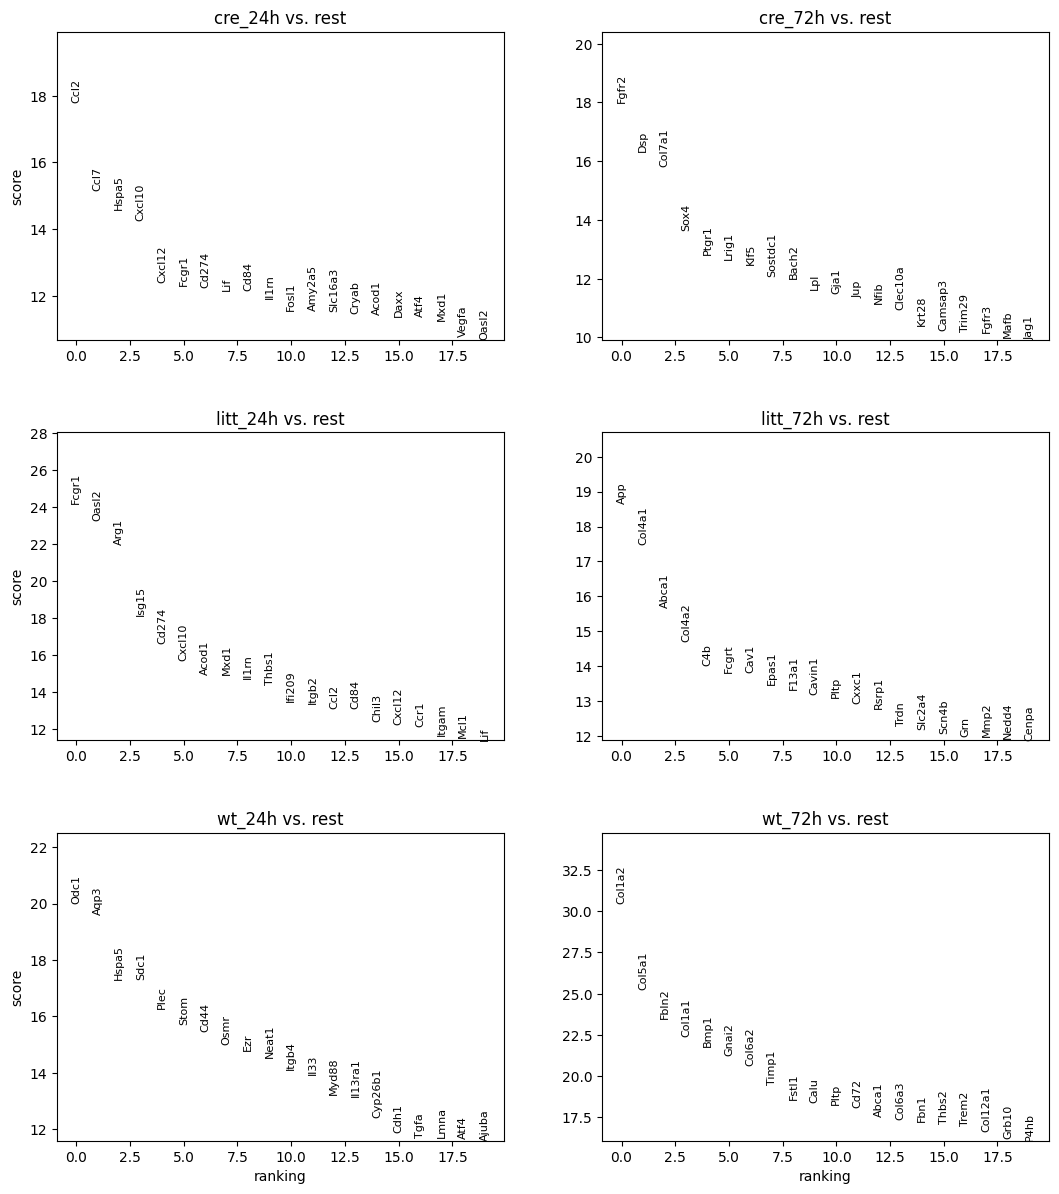

In [29]:
# Run DE between groups in adata.obs["condition"]
sc.tl.rank_genes_groups(
    ad,
    groupby="condition",          # column in .obs
    method="t-test",              # or "wilcoxon" / "logreg"
)

# Inspect results
sc.pl.rank_genes_groups(ad, n_genes=20, sharey=False, ncols= 2)

## Running DGE using built in scanpy functionality (non bulk)


=== cre_24h_vs_litt_24h ===
      gene  logfoldchange          pval      pval_adj
0    Hspa5       0.863475  6.922425e-18  3.465366e-14
1     Atf4       0.638574  3.808083e-16  9.531631e-13
2    Itgb1       0.466850  6.619450e-15  8.284241e-12
3     Il33       0.788887  3.291466e-13  3.026419e-10
4      Ezr       0.582486  3.627350e-13  3.026419e-10
5     Aqp3       0.845090  5.710302e-12  3.176197e-09
6  Slc16a3       0.485509  4.489770e-10  1.987530e-07
7    Cryab       1.209737  4.764354e-10  1.987530e-07
8      Msn       0.325354  4.716858e-09  1.574173e-06
9    Aldoa       0.417365  2.982099e-08  9.330242e-06


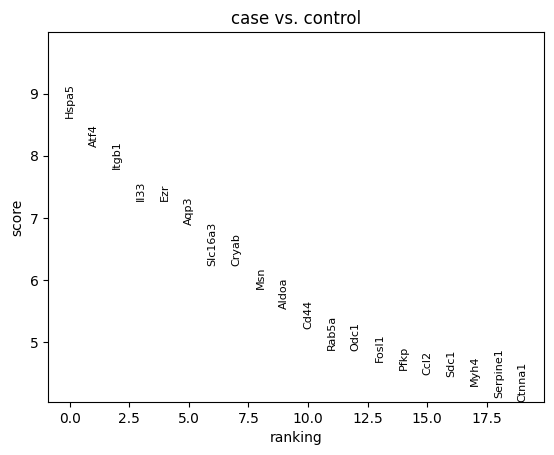


=== cre_24h_vs_wt_24h ===
      gene  logfoldchange          pval      pval_adj
0  Slc16a3       1.557166  3.277613e-48  1.640773e-44
1     Arg1       2.573691  2.964831e-20  2.120278e-17
2     Mxd1       1.213253  5.716250e-15  3.576944e-12
3     Ccl2       1.494574  5.586780e-14  2.796742e-11
4   Cxcl10       2.902903  5.801912e-12  2.234183e-09
5    Thbs1       1.497633  4.916933e-10  1.230708e-07
6    Fcgr1       1.360843  5.302318e-10  1.263972e-07
7     Cd84       2.664956  8.794734e-09  1.518153e-06
8   Cxcl12       1.707131  4.988579e-08  7.344949e-06
9    Acod1       2.384859  6.856871e-08  9.807284e-06


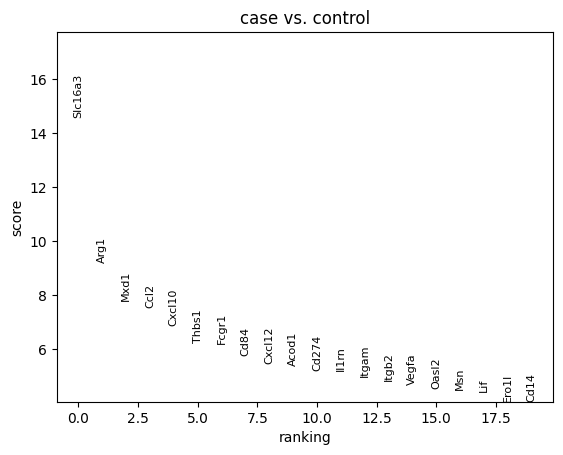


=== litt_24h_vs_wt_24h ===
      gene  logfoldchange          pval      pval_adj
0     Arg1       3.446926  4.845174e-56  2.425494e-52
1      Grn       0.810305  1.796295e-26  9.991391e-24
2  Slc16a3       1.071657  3.096378e-24  1.409134e-21
3    Fcgr1       1.614212  3.600284e-24  1.501918e-21
4    Oasl2       1.082220  2.962095e-17  7.061070e-15
5     Mxd1       1.218105  6.604526e-16  1.377594e-13
6    Itgb2       1.463816  1.225639e-14  2.359827e-12
7    Thbs1       1.545345  6.129202e-14  1.022759e-11
8    Itgam       1.135118  1.414392e-13  2.212639e-11
9    F13a1       0.964284  7.085625e-10  8.651375e-08


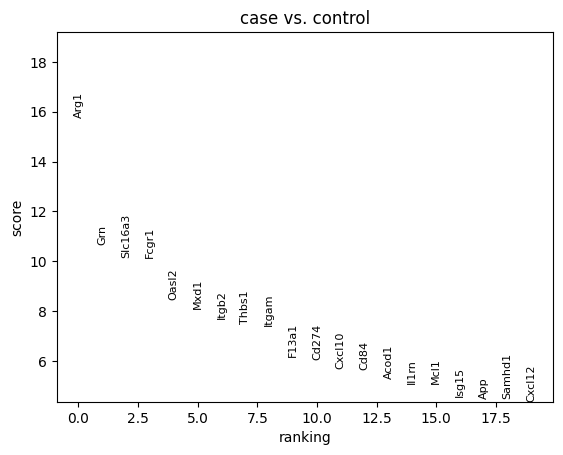


=== cre_72h_vs_litt_72h ===
     gene  logfoldchange          pval      pval_adj
0     Dsp       0.607377  5.312099e-30  1.329618e-26
1    Klf5       0.600196  7.127565e-13  2.548614e-10
2     Jup       0.342002  4.290684e-09  8.949651e-07
3   Fgfr2       0.892008  2.384566e-07  3.315872e-05
4  Col7a1       0.642554  1.287810e-06  1.461201e-04
5   Dsg1b       0.260522  1.020125e-05  9.284989e-04
6    Gja1       0.248358  1.322666e-05  1.122249e-03
7   Fgfr3       0.530784  1.923495e-05  1.481387e-03
8    Cdh1       0.329680  2.125428e-05  1.612105e-03
9    Egr3       0.497372  2.439790e-05  1.796116e-03


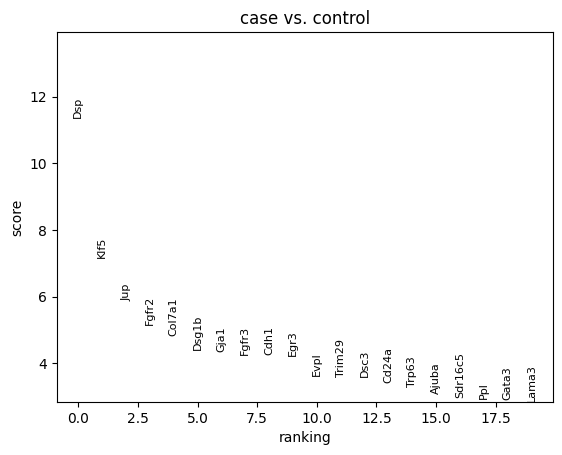


=== cre_72h_vs_wt_72h ===
    gene  logfoldchange          pval      pval_adj
0    Dsp       0.785434  4.378861e-41  7.306860e-38
1   Gja1       0.694710  1.796710e-20  8.176665e-18
2    Jup       0.655168  7.643700e-19  2.943412e-16
3  Fgfr2       1.395947  3.544920e-16  9.339932e-14
4  Fgfr3       0.902879  4.812932e-13  1.095161e-10
5   Klf5       0.628135  2.459117e-11  4.734746e-09
6   Egr3       0.650971  8.925934e-10  1.207655e-07
7   Dsc3       0.476641  1.296902e-08  1.583486e-06
8   Bcam       0.950983  1.493940e-08  1.739225e-06
9   Nfib       0.587269  6.186288e-08  6.589055e-06


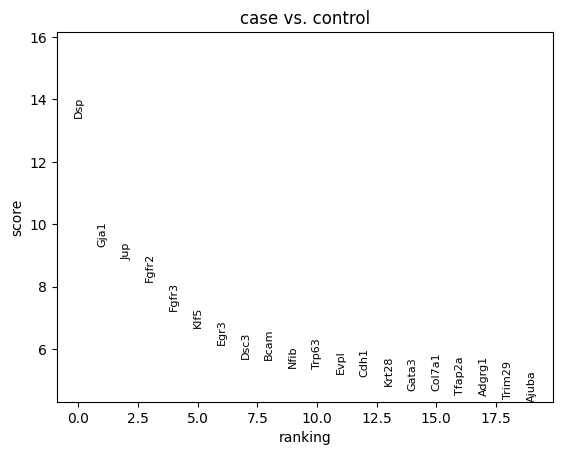


=== litt_72h_vs_wt_72h ===
     gene  logfoldchange          pval      pval_adj
0  Col4a1       0.409645  8.588771e-29  4.299539e-25
1     App       0.365810  1.408454e-15  2.350240e-12
2     C4b       1.229459  1.349005e-13  1.125520e-10
3  Slc2a4       0.573145  2.941797e-11  1.338785e-08
4   Rsrp1       0.362846  3.533815e-09  1.289082e-06
5   Ifit3       0.417798  3.605103e-09  1.289082e-06
6   Cxxc1       0.352893  1.256705e-08  3.931917e-06
7    Myh4       0.870464  1.775366e-08  5.227931e-06
8    Bcam       1.012961  7.982083e-08  2.103069e-05
9   Rab5a       0.817188  2.337070e-07  5.849686e-05


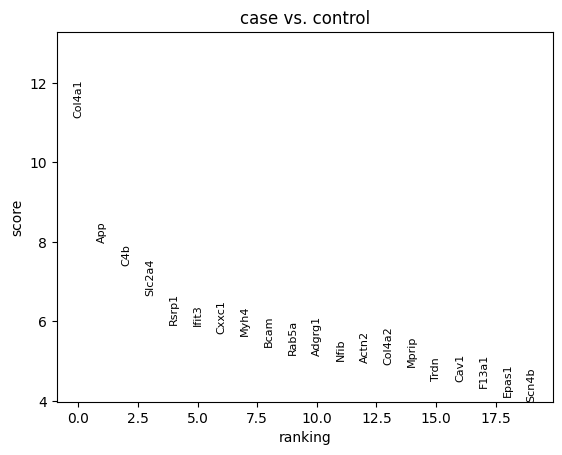

In [30]:
import scanpy as sc
import pandas as pd

results_scanpy = {}

for name, spec in comparisons.items():
    case_conditions = spec["case"]
    ctrl_conditions = spec["control"]

    # Make a temporary grouping column in .obs
    ad.obs["group_DE"] = "rest"
    ad.obs.loc[ad.obs["condition"].isin(case_conditions), "group_DE"] = "case"
    ad.obs.loc[ad.obs["condition"].isin(ctrl_conditions), "group_DE"] = "control"

    # Subset only case + control cells
    ad_sub = ad[ad.obs["group_DE"].isin(["case","control"])].copy()

    # Run DE
    sc.tl.rank_genes_groups(
        ad_sub,
        groupby="group_DE",
        method="wilcoxon",      # or "t-test"
        reference="control"     # always compare case vs control
    )

    # Save results to a tidy DataFrame
    de_res = ad_sub.uns["rank_genes_groups"]
    case_group = "case"

    df = pd.DataFrame({
        "gene": de_res["names"][case_group],
        "logfoldchange": de_res["logfoldchanges"][case_group],
        "pval": de_res["pvals"][case_group],
        "pval_adj": de_res["pvals_adj"][case_group],
    })
    results_scanpy[name] = df

    print(f"\n=== {name} ===")
    print(df.head(10))

    # Quick plot for top genes
    sc.pl.rank_genes_groups(ad_sub, n_genes=20, sharey=False, ncols=2, title=name)

In [32]:
combined_scanpy = pd.concat(results_scanpy, names=["comparison"])
combined_scanpy = combined_scanpy.reset_index(level="comparison").reset_index(drop=True)

## Export data for customer

In [33]:
combined_scanpy.to_csv('../../results/differential-gene-expression/skin_graft_non_pseudobulk_comparision.csv')

In [38]:
combined_scanpy[combined_scanpy.pval < 0.05].sort_values(by = 'logfoldchange', ascending = False).head(50)

,comparison,gene,logfoldchange,pval,pval_adj
25055,litt_72h_vs_wt_72h,Krt28,6.448201,1.615294e-04,1.796925e-02
20037,cre_72h_vs_wt_72h,Krt28,6.425565,1.382074e-06,1.081041e-04
25071,litt_72h_vs_wt_72h,Krt71,6.309228,2.496763e-03,1.865492e-01
20113,cre_72h_vs_wt_72h,Krt71,6.020693,4.140148e-02,7.509269e-01
10012,litt_24h_vs_wt_24h,Arg1,3.446926,4.845174e-56,2.425494e-52
5023,cre_24h_vs_wt_24h,Lif,3.222641,9.205434e-06,7.200375e-04
5010,cre_24h_vs_wt_24h,Cxcl10,2.902903,5.801912e-12,2.234183e-09
25073,litt_72h_vs_wt_72h,Myh2,2.812881,3.393602e-03,2.426910e-01
10035,litt_24h_vs_wt_24h,Lif,2.766102,3.681811e-04,1.491661e-02
5013,cre_24h_vs_wt_24h,Cd84,2.664956,8.794734e-09,1.518153e-06
